### Loan Data
- Link: https://www.kaggle.com/datasets/itssuru/loan-data

Mô tả ngắn về từng thuộc tính trong tập dữ liệu:

credit_policy: 1 nếu khách hàng đáp ứng đủ các tiêu chí đánh giá rủi ro tín dụng của Lending-Club.com, và 0 là ngược lại.

purpose: mục đích của khoản vay như: mở thẻ tín dụng, mua xe hơi, trang thiết bị gia đình…

int_rate: lãi suất của khoản vay.

installment: số tiền trả góp hàng tháng mà người vay phải trả góp.

log_annual_inc: logarithm thu nhập hàng năm của người vay

dti: hệ số nợ trên thu nhập (Debt to Income Ratio) là tỉ lệ phần trăm của tổng thu nhập hàng tháng để trả các khoản thanh toán nợ hàng tháng. Công thức: DTI= (Tổng các khoản thanh toán nợ hàng tháng)/(Tổng thu nhập hàng tháng)

fico: điểm FICO là điểm tín dụng của người vay. Các tổ chức Tài Chính, Ngân Hàng dựa vào điểm FICO của người vay để đánh giá rủi ro tín dụng và xác định xem có nên cấp tín dụng hay không.? . 300 – 629: tệ . 630 – 689: khá . 690 – 719: tốt . 720 – 850: xuất sắc

days_with_cr_line: Ngày được cấp hạn mức tín dụng của người vay.

revol_bal: Tín dụng quay vòng là một kiểu hạn mức tín dụng mà khách hàng trả một khoản phí cam kết cho một tổ chức tài chính để vay tiền và sau đó được phép sử dụng tiền khi cần thiết. Ví dụ: phổ biến nhất về tín dụng quay vòng là hạn mức tín dụng cá nhân.

revol_util: Tỉ lệ sử dụng nợ tín dụng là tỉ lệ phần trăm của tổng nợ tín dụng hiện có của người vay đang được sử dụng. Tỉ lệ sử dụng nợ tín dụng là một yếu tố được áp dụng bởi các cơ quan báo cáo tín dụng để tính điểm tín dụng của người vay.

inq_last_6mths: Số lượng các câu hỏi của người vay đối với tổ chức Tài Chính trong 6 tháng qua.

delinq_2yrs: Số lần người vay đã quá 30 ngày đến hạn thanh toán trong 2 năm qua.

pub_rec: Thông tin về lịch sử tín dụng của bên vay (báo cáo tín dụng) mà bên cho vay có thể sử dụng hợp pháp, để bác bỏ yêu cầu vay hoặc đơn xin vay tín dụng. Bao gồm những việc như phá sản, thanh toán trễ hạn và các khoản vay đã xóa bỏ trước đây.

not_fully_paid: thông tin cho biết khoản vay có được hoàn trả hay không

0: Khoản vay đã thanh toán đầy đủ

1: Khoản vay chưa thanh toán đầy đủ

### Import the libraries

In [1]:
import numpy as np
import pandas as pd
from timeit import default_timer as timer
from datetime import datetime
import time
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from scipy import stats
from scipy.stats import skew, norm
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics, tree
import graphviz
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler, normalize
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, classification_report, precision_recall_curve
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split, KFold
from imblearn.over_sampling import SMOTE
from sklearn.datasets import make_classification


# Others
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

cmap=sns.color_palette('Blues_r')

In [2]:
# Import data
df=pd.read_csv('loan_data.csv')

In [3]:
# Change the sign. in column names with
df.columns = [c.replace(".","_") for c in df.columns]
print(f"Số lượng bản ghi: {df.shape[0]}")
print(f"Số lượng thuộc tính: {df.shape[1]}")
df.sample(5)

Số lượng bản ghi: 9578
Số lượng thuộc tính: 14


,credit_policy,purpose,int_rate,installment,log_annual_inc,dti,fico,days_with_cr_line,revol_bal,revol_util,inq_last_6mths,delinq_2yrs,pub_rec,not_fully_paid
4278,1,home_improvement,0.1253,502.00,11.289782,0.13,802,7102.000000,9,0.1,0,0,0,0
2759,1,debt_consolidation,0.1347,244.25,11.390758,12.83,687,3510.000000,28767,74.9,1,0,0,0
5059,1,major_purchase,0.0740,83.86,11.511925,0.18,802,6179.958333,1269,2.0,2,0,0,0
2266,1,credit_card,0.1347,339.23,11.082143,8.51,697,4530.041667,15351,77.9,1,0,0,0
5426,1,all_other,0.1218,166.50,10.596635,5.64,697,2730.000000,4388,43.9,0,0,0,0


### Visualization

In [4]:
def create_var_dictionary_dataframe():
  # Initialize an empty DataFrame
  variabels = pd.DataFrame(columns=['Variable', 'Number of unique values','DataType', 'Number of nulls', 'Values'])
  # Iterate through each column in the dataset
  for i, var in enumerate(df.columns):
    # Get unique values and null count for the current variable
    unique_values = df[var].unique()
    data_type = df[var].dtype
    null_count = df[var].isnull().sum()
    # Add a row to the DataFrame with the variable information
    variabels.loc[i] = [var, len(unique_values), data_type, null_count, unique_values[:5].tolist()]

  return variabels

# Create the variable dictionary DataFrame
var_dict = create_var_dictionary_dataframe()

# Display the DataFrame
print(f"Số lượng bản ghi: {df.shape[0]}")
print(f"Số lượng thuộc tính: {df.shape[1]}")
print(var_dict.to_string(index=False))

Số lượng bản ghi: 9578
Số lượng thuộc tính: 14
         Variable  Number of unique values DataType  Number of nulls                                                                         Values
    credit_policy                        2    int64                0                                                                         [1, 0]
          purpose                        7   object                0 [debt_consolidation, credit_card, all_other, home_improvement, small_business]
         int_rate                      249  float64                0                                       [0.1189, 0.1071, 0.1357, 0.1008, 0.1426]
      installment                     4788  float64                0                                        [829.1, 228.22, 366.86, 162.34, 102.92]
   log_annual_inc                     1987  float64                0              [11.35040654, 11.08214255, 10.37349118, 11.29973224, 11.90496755]
              dti                     2529  float64              

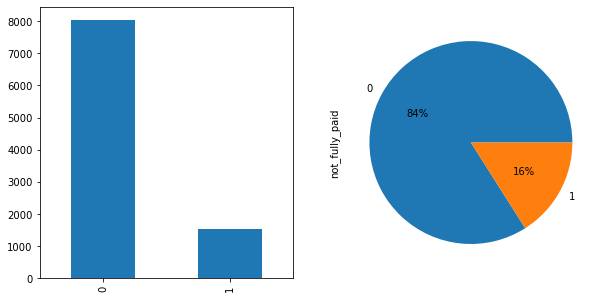

In [5]:
# Loan payment rate - Tỷ lệ thanh toán khoản vay
fig, axs = plt.subplots(1,2,figsize=(10,5))
df['not_fully_paid'].value_counts().plot(kind='bar',ax=axs[0])
df['not_fully_paid'].value_counts().plot(kind='pie', autopct='%.0f%%', ax=axs[1])
plt.show()

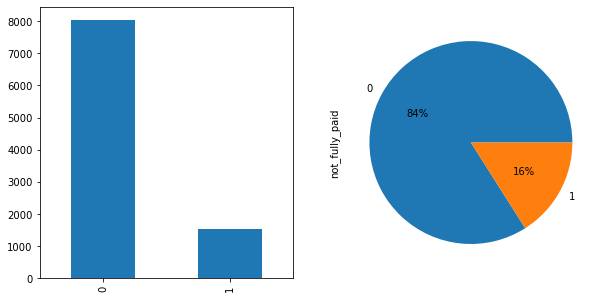

In [6]:
# Loan payment rate - Tỷ lệ thanh toán khoản vay
fig, axs = plt.subplots(1,2,figsize=(10,5))
df['not_fully_paid'].value_counts().plot(kind='bar',ax=axs[0])
df['not_fully_paid'].value_counts().plot(kind='pie', autopct='%.0f%%', ax=axs[1])
plt.show()

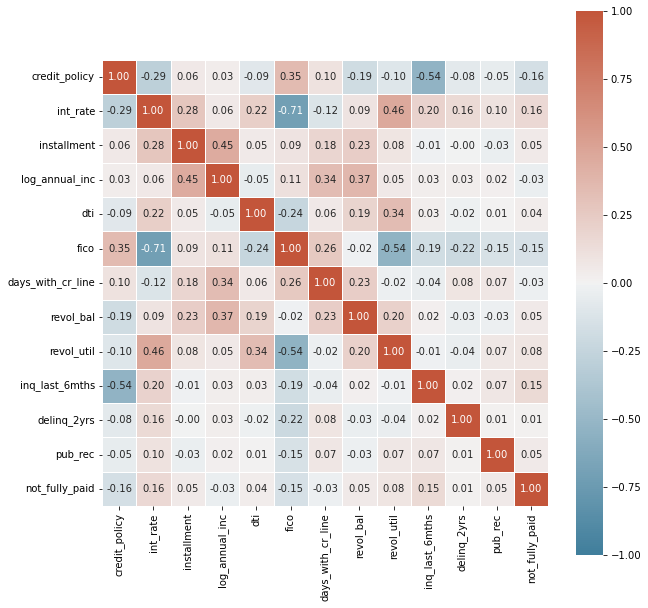

In [7]:
# Correlation between attributes - Tương quan giữa các thuộc tính số và biến phân loại
plt.figure(figsize=(10,10))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
df_corr=df.drop(['purpose'], axis=1)
corr_maxtrix = df_corr.corr()
sns.heatmap(corr_maxtrix, cmap=cmap, center=0, square=True, linewidths=.5, vmin=-1, vmax=1, fmt=".2f",annot=True)
plt.show()

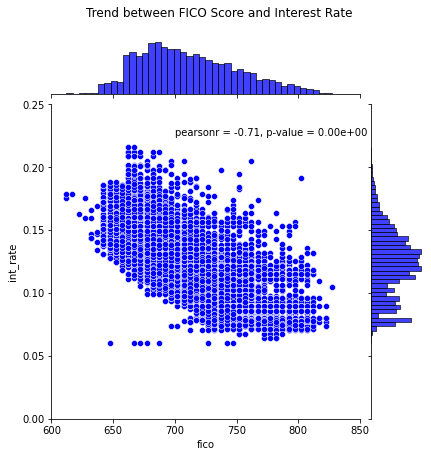

In [8]:
# Trend between FICO Score and Interest Rate - Xu hướng tương quan giữa điểm fico và lãi suất khoản vay
from scipy.stats import pearsonr

# Calculate the Pearson correlation coefficient and p-value
corr_coeff, p_value = pearsonr(df['fico'], df['int_rate'])

# Create the jointplot
joint = sns.jointplot(data=df, x='fico', y='int_rate', kind='scatter', color='blue')

# Set the x-axis and y-axis limits
joint.ax_joint.set_xlim(600, 850)
joint.ax_joint.set_ylim(0, 0.25)

# Add the Pearson correlation coefficient and p-value to the plot
joint.ax_joint.annotate(f'рearsonr = {corr_coeff:.2f}, p-value = {p_value:.2e}', xy=(0.4, 0.9), xycoords='axes fraction', fontsize=10)


# Move the title to the top
joint.fig.suptitle('Trend between FICO Score and Interest Rate', y=1.05)

# Show the plot
plt.show()

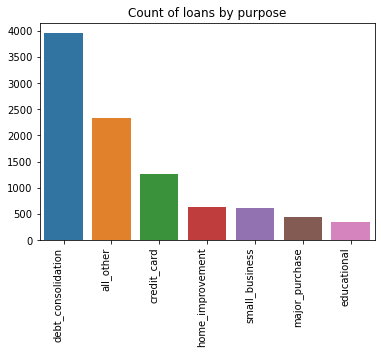

In [9]:
# Count of loans by purpose
# create the countplot
sns.countplot(x=df.purpose, order=df.purpose.value_counts().index)

# adjust tick label rotation and spacing
plt.xticks(rotation=90, ha='right')
plt.gcf().subplots_adjust(wspace=0.2)

# remove the x and y labels
plt.xlabel(None)
plt.ylabel(None)

# add a title
plt.title("Count of loans by purpose")
plt.show()

Text(0, 0.5, '')

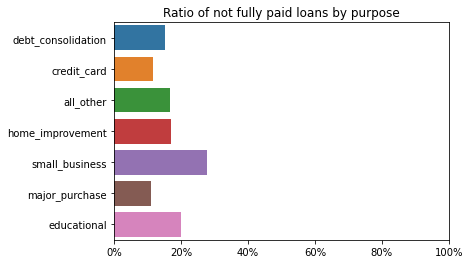

In [10]:
# Ratio of not fully paid loans by purpose - Tỷ lệ khoản vay chưa được thanh toán đầy đủ theo mục đích vay
ax = sns.barplot(y=df.purpose, x=df.not_fully_paid.astype('int'), ci=None)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
plt.title("Ratio of not fully paid loans by purpose")
plt.xlim(0, 1)
plt.xlabel(None)
plt.ylabel(None)


In [11]:
# Binning 'fico' scores into categories
df['fico_category'] = pd.cut(df['fico'], bins=[300, 630, 690, 720, 850], labels=['Tệ (300-629)', 'Khá (630-689)', 'Tốt (690-719)', 'Xuất sắc (720-850)'])

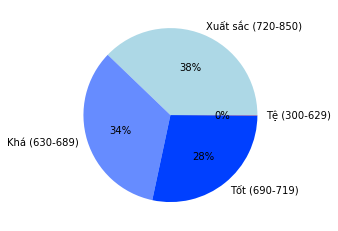

In [12]:
# Tính toán số lượng mỗi nhóm và đặt lại tên cột
x = df['fico_category'].value_counts().reset_index()

# Đặt lại tên cột 'index' thành 'fico_category' và 'fico_category' thành 'count'
x.columns = ['fico_category', 'count']

# Tạo biểu đồ pie
colors = ['#ADD8E6', '#668cff', '#0040FF', '#FF6347']
plt.pie(x['count'], labels=x['fico_category'], colors=colors, autopct='%.0f%%')
plt.show()

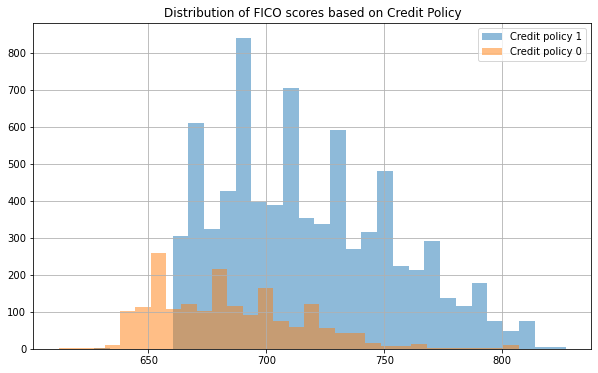

In [13]:
# Distribution of FICO scores based on Credit Policy
# Set up the matplotlib figure
plt.figure(figsize=(10,6))

# Plot histogram for FICO scores where credit_policy is 1
df[df['credit_policy']==1]['fico'].hist(alpha=0.5, bins=30, label='Credit policy 1')
# Plot histogram for FICO scores where credit_policy is 0
df[df['credit_policy']==0]['fico'].hist(alpha=0.5, bins=30, label='Credit policy 0')

# Add labels and title
plt.title('Distribution of FICO scores based on Credit Policy')
plt.legend()
plt.show()

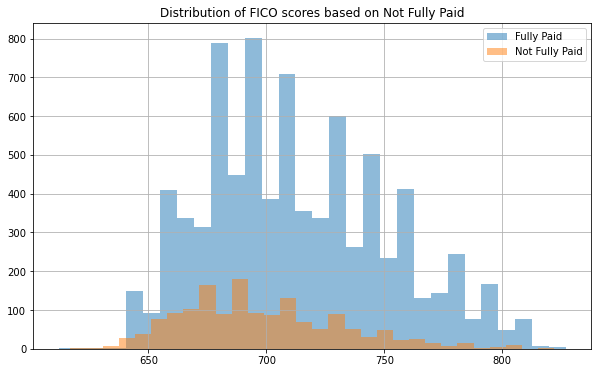

In [14]:
# Distribution of FICO scores based on Not Fully Paid
# Set up the matplotlib figure
plt.figure(figsize=(10,6))

# Plot histogram for FICO scores where not_fully_paid is 0
df[df['not_fully_paid']==0]['fico'].hist(alpha=0.5, bins=30, label='Fully Paid')

# Plot histogram for FICO scores where not_fully_paid is 1
df[df['not_fully_paid']==1]['fico'].hist(alpha=0.5, bins=30, label='Not Fully Paid')

# Add labels and title
plt.title('Distribution of FICO scores based on Not Fully Paid')
plt.legend()
plt.show()

In [15]:
# Statistical description of the target variable
df.groupby('not_fully_paid')["fico"].describe()

,count,mean,std,min,25%,50%,75%,max
not_fully_paid,,,,,,,,
0,8045.0,713.326911,38.223723,612.0,682.0,707.0,742.0,827.0
1,1533.0,697.828441,33.756808,617.0,672.0,692.0,717.0,822.0


In [16]:
# Group by 'not_fully_paid' and 'purpose', and count the number of each group
x = df.groupby(['not_fully_paid', 'purpose']).size().unstack(fill_value=0)
# Rename the columns
x.columns.name = None

# Display the DataFrame x
x

,all_other,credit_card,debt_consolidation,educational,home_improvement,major_purchase,small_business
not_fully_paid,,,,,,,
0,1944,1116,3354,274,522,388,447
1,387,146,603,69,107,49,172


(0.0, 1.0)

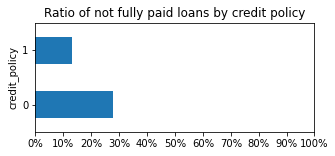

In [17]:
# Ratio of not fully paid loans by to credit policy - Tỷ lệ khoản vay không thanh toán đầy đủ theo chính sách tín dụng
ratio = df.groupby('credit_policy')['not_fully_paid'].mean()
ax=ratio.plot.barh(figsize=(5,2), title="Ratio of not fully paid loans by credit policy")

ax.xaxis.set_major_formatter(mtick.PercentFormatter(1,decimals=0))
# Set the x-axis major tick locator
# Set ticks every 10%
ax.xaxis.set_major_locator(mtick.MultipleLocator(0.1))

plt.xlim(0,1)

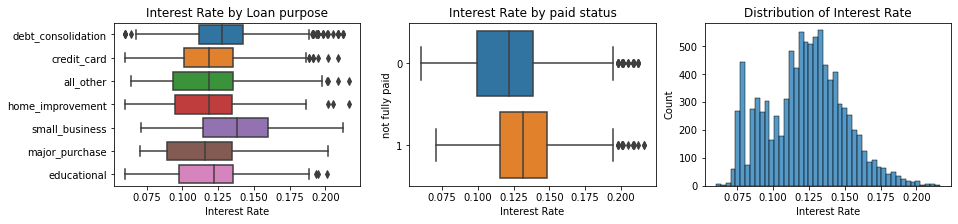

In [18]:
# Definition represents the distribution of attributes - Hàm thể hiện sự phân bố của thuộc tính
def show_distribution(feature, name):
  fig, axes = plt.subplots (1,3, figsize=(15,3))

#plot the boxplots by purpose
  sns.boxplot(data=df, x=feature, y='purpose', ax=axes[0],)
  axes[0].set_ylabel("")
  axes[0].set_xlabel(name)
  axes[0].set_title(name+" by Loan purpose", fontsize=12)

  # plot the boxplots by not fully_paid
  y=df.not_fully_paid.astype("category")
  sns.boxplot(data=df, x=feature, y=y, ax=axes[1])
  axes[1].set_ylabel("not fully paid")
  axes[1].set_xlabel(name)
  axes[1].set_title(name+" by paid status", fontsize=12)

  # plot the feature distribution
  sns.histplot(x=df[feature], cumulative=False, ax=axes[2])
  axes[2].set_xlabel(name)
  axes[2].set_title("Distribution of " +name, fontsize=12)
show_distribution('int_rate','Interest Rate')

Biểu đồ đầu tiên cho thấy mục đích của khoản vay không ảnh hưởng nhiều đến lãi suất vì chúng ta thấy các ô ở cùng một vị trí cho từng mục đích. Tuy nhiên, có một ngoại lệ: các khoản vay dành cho doanh nghiệp nhỏ thường có lãi suất cao hơn các doanh nghiệp còn lại; mức trung bình của chúng cao hơn phân vị thứ 75 (cạnh bên phải của ô) của các mục đích khác. Điều này có nghĩa là 75% các khoản vay cho các mục đích khác có lãi suất thấp hơn lãi suất trung bình dành cho các khoản vay dành cho doanh nghiệp nhỏ.

Biểu đồ thứ hai cho thấy các khoản vay không được trả đầy đủ có lãi suất cao hơn một chút, nhưng không đáng kể. Trong biểu đồ thứ ba, chúng ta thấy rằng lãi suất có xu hướng tuân theo phân phối chuẩn với rất nhiều khoản vay bổ sung có lãi suất thấp hơn mức trung bình, làm lệch phân phối sang trái một chút.

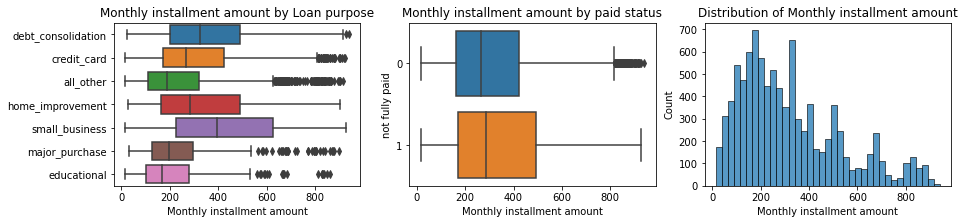

In [19]:
show_distribution("installment","Monthly installment amount")

Chúng ta có thể thấy rằng số tiền trả góp thay đổi liên quan đến mục đích của khoản vay, trong đó các khoản vay dành cho doanh nghiệp nhỏ, hợp nhất nợ & sửa nhà có phạm vi trả góp cao nhất. Số tiền trả góp dường như không liên quan gì đến việc trả nợ, sự khác biệt là không đáng kể. Việc phân bổ số tiền trả góp cho thấy hầu hết các khoản vay đều có số tiền trả góp thấp hơn, dưới 400 USD.

So sánh số liệu thống kê tóm tắt về số tiền trả góp của các khoản vay dành cho doanh nghiệp nhỏ so với tất cả các khoản còn lại một cách chi tiết hơn:

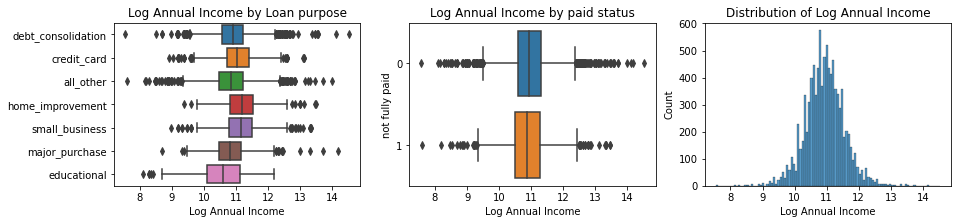

In [20]:
show_distribution('log_annual_inc','Log Annual Income')

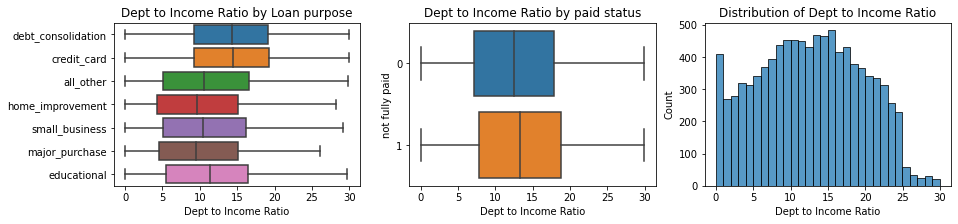

In [21]:
show_distribution('dti','Dept to Income Ratio')

Có vẻ như những người có tỷ lệ nợ trên thu nhập cao hơn, tức là những người có khoản nợ lớn hơn, có xu hướng vay tiền để hợp nhất nợ và cấp vốn bằng thẻ tín dụng. Dti dường như không ảnh hưởng lớn đến việc khoản vay có được trả đầy đủ hay không. Sự phân bổ cho thấy rất nhiều khoản vay được thực hiện bởi những người có dti 0 hoặc dti ở phạm vi thấp hơn và rất ít người có dti cao hơn 25.

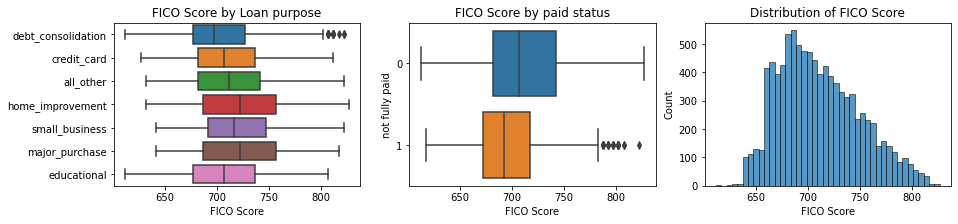

In [22]:
show_distribution('fico','FICO Score')

In [23]:
# Get numerical feature columns - Lấy các cột thuộc tính dữ liệu số
# Separate data to include numerical data only
numfeat_cols = df[["int_rate","installment","log_annual_inc","dti","fico","days_with_cr_line", "revol_bal","revol_util","inq_last_6mths", "delinq_2yrs","pub_rec"]]

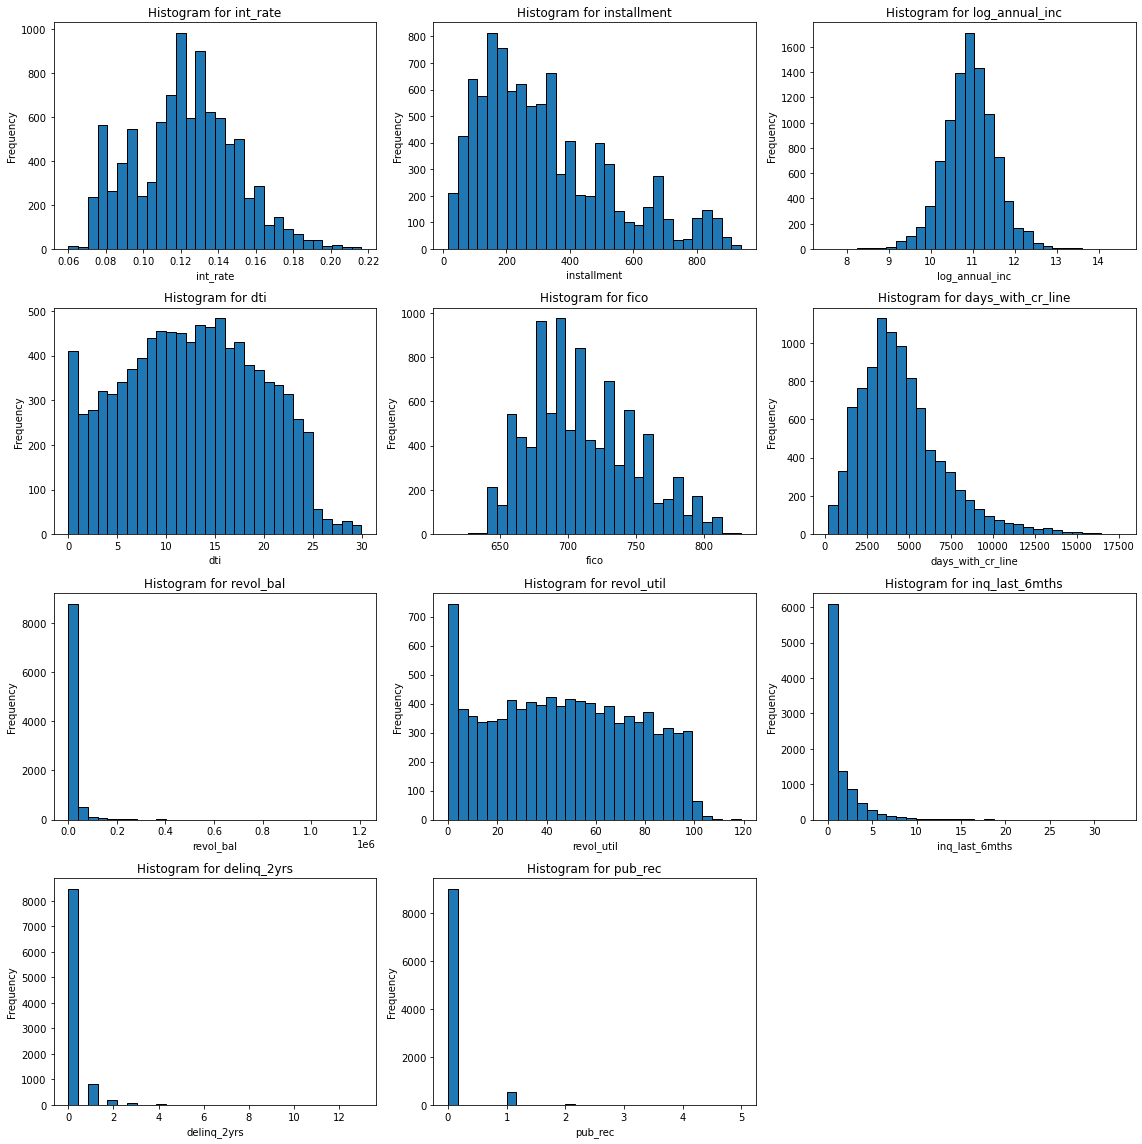

In [24]:
# Set the number of bins for the histograms
num_bins = 30  

# Calculate the number of rows and columns for subplots
num_features = len(numfeat_cols.columns)
num_rows = (num_features - 1) // 3 + 1
num_cols = min(3, num_features)

# Create subplots for each numerical feature
plt.figure(figsize=(16, 4 * num_rows))  
for i, column in enumerate(numfeat_cols.columns, 1):
    plt.subplot(num_rows, num_cols, i)
    plt.title(f'Histogram for {column}')
    plt.hist(df[column], bins=num_bins, edgecolor='k')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [25]:
# numbers = df.select_dtypes(['int64', 'float64']).columns
gr1 = ['int_rate', 'installment', 'log_annual_inc', 'dti',
       'fico', 'days_with_cr_line', 'revol_bal', 'revol_util']

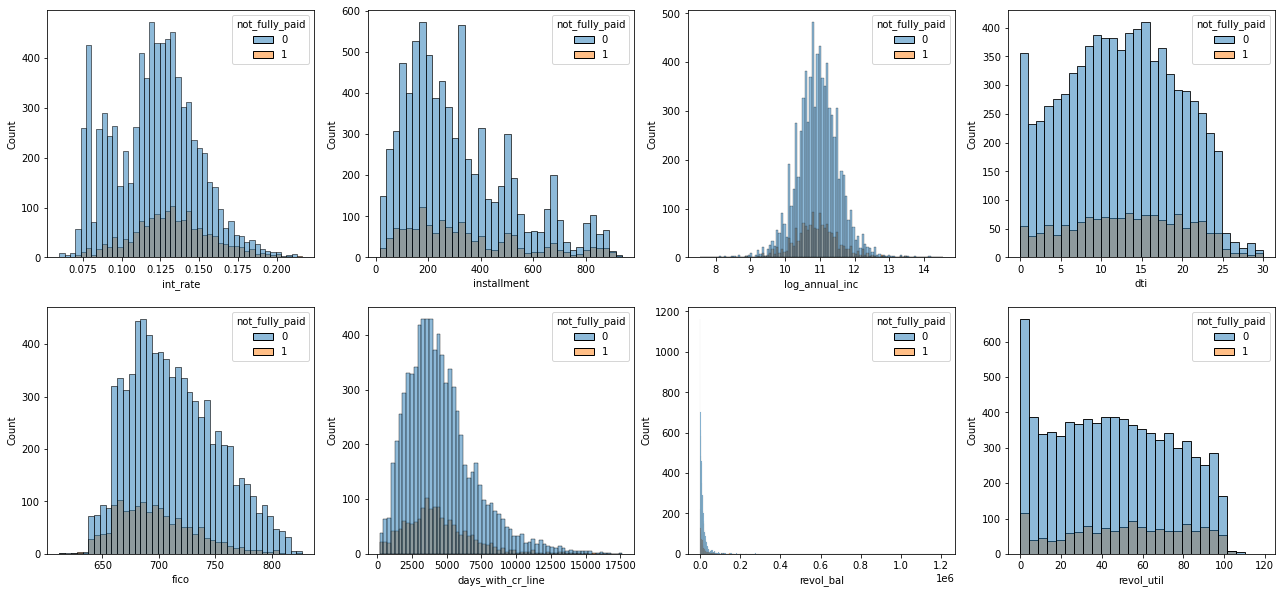

In [26]:
#  Create subplots 
fig, ax = plt.subplots(2, 4, figsize=(22, 10))
ax = ax.ravel()
count = 0
for i in gr1:
    sns.histplot(data=df, x=i, hue='not_fully_paid', ax=ax[count])
    count += 1

# Display the figure
plt.show()


In [27]:
df_des = df.groupby('not_fully_paid')[gr1].agg(['mean', 'std'])
df_des

int_rate           installment             log_annual_inc  \
                    mean       std        mean         std           mean   
not_fully_paid                                                              
0               0.120770  0.026692  314.574123  203.398688      10.941091   
1               0.132452  0.025495  342.785114  223.948527      10.885023   

                                dti                  fico             \
                     std       mean       std        mean        std   
not_fully_paid                                                         
0               0.604045  12.494413  6.855020  713.326911  38.223723   
1               0.666718  13.195838  7.006769  697.828441  33.756808   

               days_with_cr_line                  revol_bal                \
                            mean          std          mean           std   
not_fully_paid                                                              
0                    4592.632624  2508.035500  16122.724425  29637.645740   
1                    4393.541259  2431.785491  21066.293542  49905.689359   

               revol_util             
                     mean        std  
not_fully_paid                        
0               45.759608  28.891285  
1               52.255075  29.057906

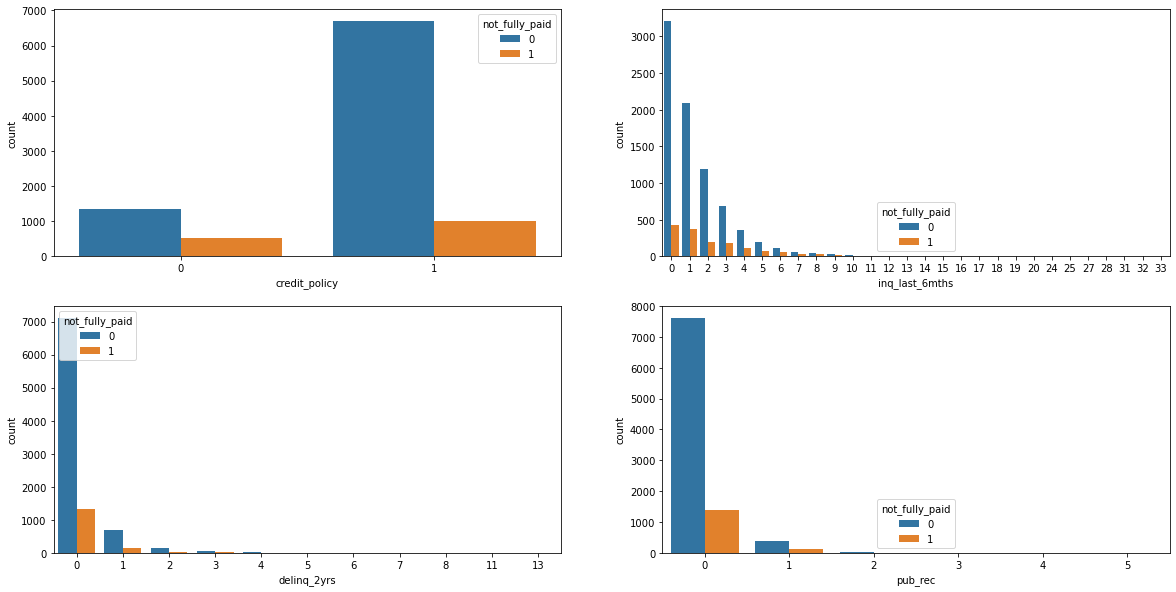

In [28]:
gr2 = ['credit_policy', 'inq_last_6mths', 'delinq_2yrs', 'pub_rec']

# Viz
fig, ax = plt.subplots(2,2, figsize=(20,10))
ax=ax.ravel()
count=0
for i in gr2:
    sns.countplot(x=i, data=df, hue='not_fully_paid', ax=ax[count])
    count+=1

plt.show()

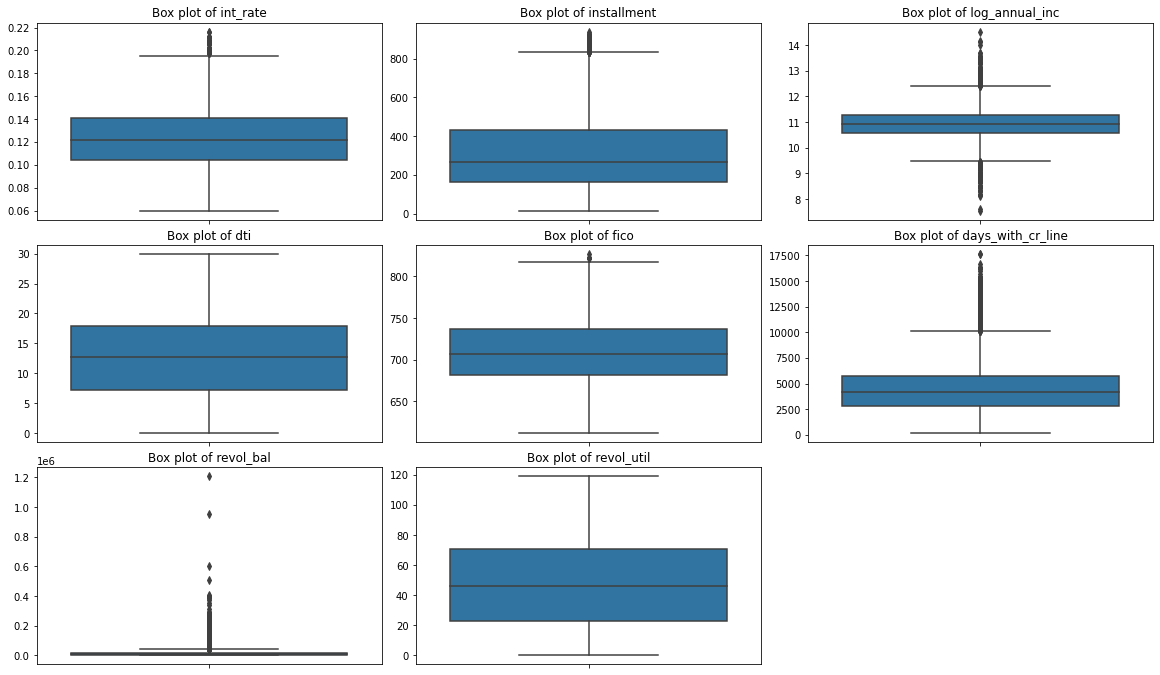

In [49]:
# Define the columns to plot
df_columns = df[["int_rate", "installment", "log_annual_inc", "dti", "fico",
                   "days_with_cr_line", "revol_bal", "revol_util"]]

# Number of df_columns to plot
num_cols = len(df_columns.columns)

# Create subplots
fig, ax = plt.subplots(nrows=4, ncols=3, figsize=(16, 12), constrained_layout=True)

# Flatten the array of subplots for easier management
ax = ax.ravel()

# Plot box plots for each column
for i, col in enumerate(df_columns.columns):
    sns.boxplot(y=df_columns[col], ax=ax[i])
    ax[i].set_title(f'Box plot of {col}')
    ax[i].set_ylabel('')

# Remove the empty subplot if any
for j in range(i + 1, len(ax)):
    fig.delaxes(ax[j])

# Display the figure
plt.show()


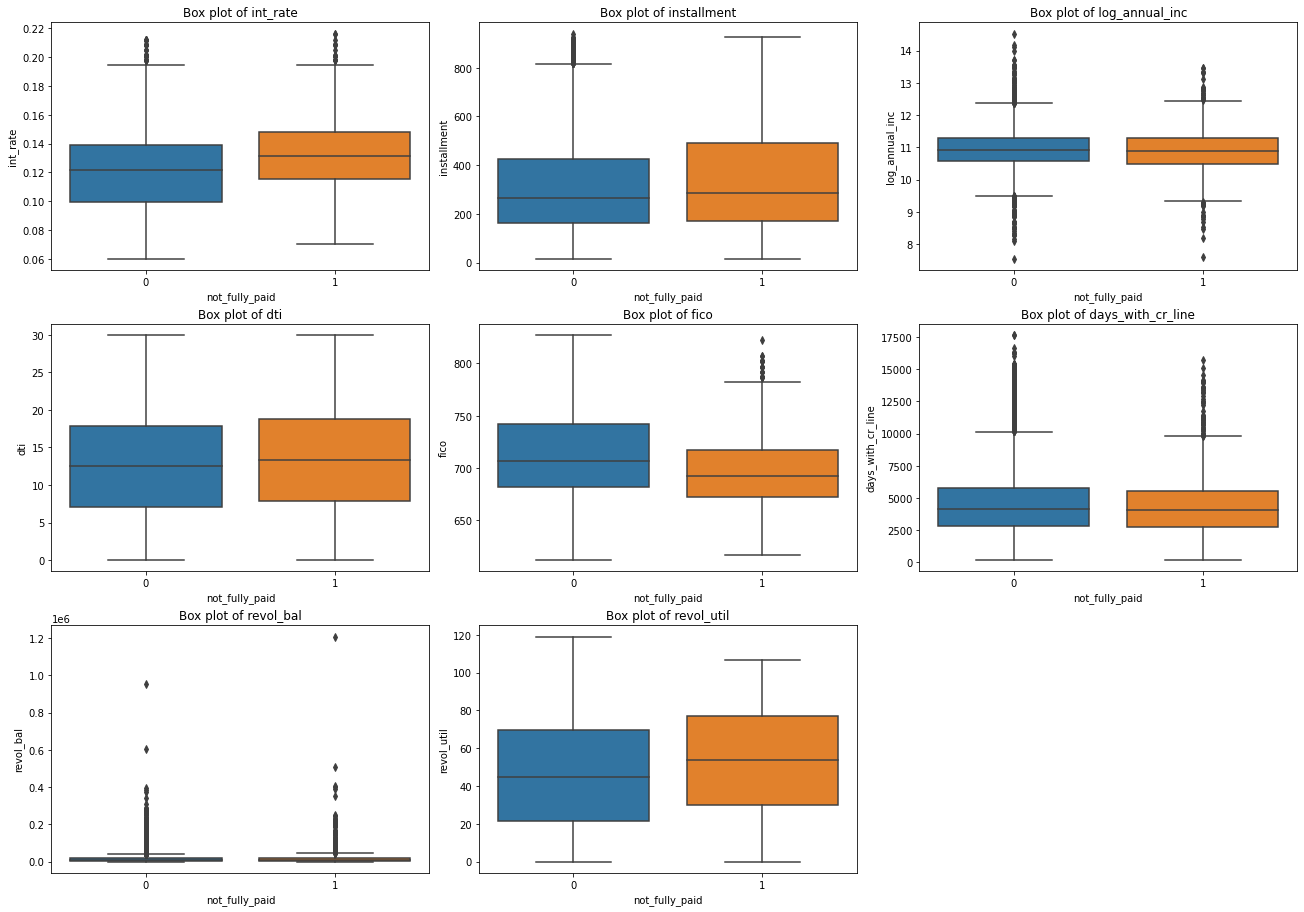

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the columns to plot
numfeat_cols = df[["int_rate", "installment", "log_annual_inc", "dti", "fico",
                   "days_with_cr_line", "revol_bal", "revol_util"]]

# Number of columns to plot
num_cols = len(numfeat_cols.columns)

# Create subplots with 4 rows and 3 columns
fig, ax = plt.subplots(nrows=4, ncols=3, figsize=(18, 16), constrained_layout=True)

# Flatten the array of subplots for easier management
ax = ax.ravel()

# Plot box plots for each column with hue='not_fully_paid'
for i, col in enumerate(numfeat_cols.columns):
    sns.boxplot(x='not_fully_paid', y=col, data=df, ax=ax[i])
    ax[i].set_title(f'Box plot of {col}')

# Remove any empty subplots (if there are fewer columns than subplots)
for j in range(num_cols, len(ax)):
    fig.delaxes(ax[j])

# Display the figure
plt.show()


### 1. Pre-processing data

#### 1.1 Train, Test split

In [32]:
# Create train and test sets
train, test = train_test_split(df, test_size=0.3, random_state=0)
train.head()

,credit_policy,purpose,int_rate,installment,log_annual_inc,dti,fico,days_with_cr_line,revol_bal,revol_util,inq_last_6mths,delinq_2yrs,pub_rec,not_fully_paid,fico_category
872,1,home_improvement,0.0768,155.95,10.596635,11.49,797,6959.958333,257,1.4,0,0,0,0,Xuất sắc (720-850)
4184,1,all_other,0.1287,94.18,10.721614,3.52,682,4289.958333,2391,30.7,1,0,0,1,Khá (630-689)
3170,1,small_business,0.1189,505.76,11.407565,9.44,737,3029.958333,5137,24.2,0,0,0,1,Xuất sắc (720-850)
4677,1,debt_consolidation,0.1114,360.84,10.757733,10.39,722,2193.000000,10735,34.5,3,0,0,0,Xuất sắc (720-850)
4884,1,major_purchase,0.1218,149.85,11.338572,0.07,707,3660.000000,5,0.1,0,0,0,0,Tốt (690-719)


In [33]:
# Train: X and y split
X_train = train.drop('not_fully_paid', axis=1)
y_train = train[['not_fully_paid']]
X_train.head()

,credit_policy,purpose,int_rate,installment,log_annual_inc,dti,fico,days_with_cr_line,revol_bal,revol_util,inq_last_6mths,delinq_2yrs,pub_rec,fico_category
872,1,home_improvement,0.0768,155.95,10.596635,11.49,797,6959.958333,257,1.4,0,0,0,Xuất sắc (720-850)
4184,1,all_other,0.1287,94.18,10.721614,3.52,682,4289.958333,2391,30.7,1,0,0,Khá (630-689)
3170,1,small_business,0.1189,505.76,11.407565,9.44,737,3029.958333,5137,24.2,0,0,0,Xuất sắc (720-850)
4677,1,debt_consolidation,0.1114,360.84,10.757733,10.39,722,2193.000000,10735,34.5,3,0,0,Xuất sắc (720-850)
4884,1,major_purchase,0.1218,149.85,11.338572,0.07,707,3660.000000,5,0.1,0,0,0,Tốt (690-719)


In [34]:
# Test: X and y split
X_test = test.drop('not_fully_paid', axis=1)
y_test = test[['not_fully_paid']]
X_test.head()

,credit_policy,purpose,int_rate,installment,log_annual_inc,dti,fico,days_with_cr_line,revol_bal,revol_util,inq_last_6mths,delinq_2yrs,pub_rec,fico_category
3343,1,all_other,0.1189,49.75,10.829729,16.87,687,2314.958333,962,64.1,0,0,0,Khá (630-689)
9,1,debt_consolidation,0.1221,84.12,10.203592,10.00,707,2730.041667,5630,23.0,1,0,0,Tốt (690-719)
1741,1,debt_consolidation,0.1695,712.54,11.918391,13.61,672,4830.041667,16473,94.1,2,2,0,Khá (630-689)
5160,1,debt_consolidation,0.1739,286.78,11.189962,19.59,667,7020.000000,19892,67.0,1,0,1,Khá (630-689)
7760,0,credit_card,0.1312,202.51,9.392662,4.40,657,898.958333,5251,49.3,9,0,0,Khá (630-689)


#### 1.2 Transform data

In [35]:
# Transform categorial features to num
X_train = pd.get_dummies(data=X_train)
X_test = pd.get_dummies(data=X_test)

In [36]:
# Log transform function
def log_transform (data, to_log):
  X = data.copy()
  for item in to_log:
    X[item] = np.log(1+X[item])
  return X

In [37]:
# Log transform
to_log = ['revol_bal']
X_train= log_transform(X_train, to_log)
X_test= log_transform(X_test, to_log)

#### 1.3 Feature Selection

In [69]:
for i in range(1,20):

    select = RFE(RandomForestClassifier(n_estimators=100, random_state=42), n_features_to_select=i)
    select.fit(X_train, y_train)
    mask = select.get_support()
    X_train_rfe = select.transform(X_train)
    X_test_rfe = select.transform(X_test)

    score = RandomForestClassifier().fit(X_train_rfe, y_train).score(X_test_rfe, y_test)

    print("Test score: {:.3f}".format(score), " number of features: {}".format(i))
# Test score: 0.751  number of features: 1
# Test score: 0.816  number of features: 2
# Test score: 0.840  number of features: 3
# Test score: 0.842  number of features: 4
# Test score: 0.841  number of features: 5
# Test score: 0.842  number of features: 6
# Test score: 0.842  number of features: 7
# Test score: 0.841  number of features: 8
# Test score: 0.839  number of features: 9
# Test score: 0.842  number of features: 10
# Test score: 0.838  number of features: 11
# Test score: 0.843  number of features: 12
# Test score: 0.841  number of features: 13
# Test score: 0.840  number of features: 14
# Test score: 0.840  number of features: 15
# Test score: 0.842  number of features: 16
# Test score: 0.840  number of features: 17
# Test score: 0.841  number of features: 18
# Test score: 0.842  number of features: 19


In [70]:
select = RFE(RandomForestClassifier(n_estimators=100, random_state=42), n_features_to_select=12)

select.fit(X_train, y_train)
mask = select.get_support()
X_train_rfe = select.transform(X_train)
X_test_rfe = select.transform(X_test)
score = RandomForestClassifier().fit(X_train_rfe, y_train).score(X_test_rfe, y_test)
print("Test score: {:.3f}".format(score), " number of features: {}".format(10))

features = pd.DataFrame({'features':list(X_train.columns), 'select':list(mask)})
display(features.T)
features = list(features[features['select']==True]['features'])
print("The selected features are: " "\n")
display(features)

In [78]:
X_train=X_train[['credit_policy','int_rate', 'installment', 'log_annual_inc', 'dti','fico',
 'days_with_cr_line', 'revol_bal', 'revol_util','inq_last_6mths','delinq_2yrs','purpose_debt_consolidation']]


X_test=X_test[['credit_policy','int_rate', 'installment', 'log_annual_inc', 'dti','fico',
 'days_with_cr_line', 'revol_bal', 'revol_util','inq_last_6mths','delinq_2yrs','purpose_debt_consolidation']]

#### 1.4 Handling Imbalanced data

In [79]:
# Transform the dataset using SMOTE
oversample = SMOTE()
X_train_sm, y_train_sm = oversample.fit_resample(X_train, y_train)

### 2. Model

In [46]:
def find_best_params(model_name, model, param_grid, X_train, y_train, X_test, y_test):
    # Create a GridSearchCV object
    grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1, scoring='f1')

    # Train the model
    grid_search.fit(X_train, y_train)

    # Get the optimal parameters
    best_params = grid_search.best_params_
    print("Optimal hyperparameters for", model_name, ":", best_params)

    # Train the model with optimal parameters on the entire training set
    best_model = model.set_params(**best_params)
    best_model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = best_model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    print("Accuracy:", accuracy)
    print("F1-score:", f1)
    print("Precision:", precision)
    print("Recall:", recall)
    print("Confusion Matrix:\n", conf_matrix)
    print("ROC AUC Score:", roc_auc)

    # Plot ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label='ROC Curve (Area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

#### 2.1 Decision Tree

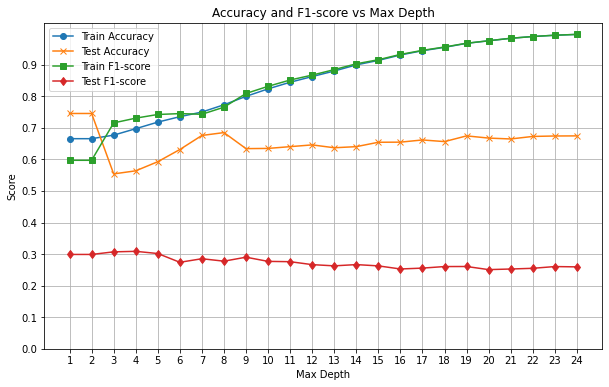

In [168]:
# Initialize lists to store results
max_depths = list(range(1, 25))
train_accuracies = []
test_accuracies = []
train_f1_scores = []
test_f1_scores = []

# Iterate through max_depth values from 1 to 25
for depth in max_depths:
    # Initialize and train the Decision Tree model with max_depth set to depth
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train_sm, y_train_sm)
    
    # Predict on the train set and calculate accuracy and F1-score
    train_pred = model.predict(X_train_sm)
    train_acc = accuracy_score(y_train_sm, train_pred)
    train_f1 = f1_score(y_train_sm, train_pred)
    
    # Predict on the test set and calculate accuracy and F1-score
    test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, test_pred)
    test_f1 = f1_score(y_test, test_pred)
    
    # Save results to the lists
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    train_f1_scores.append(train_f1)
    test_f1_scores.append(test_f1)

# Plot the results
plt.figure(figsize=(10, 6))

# Plot train and test accuracies
plt.plot(max_depths, train_accuracies, marker='o', label='Train Accuracy')
plt.plot(max_depths, test_accuracies, marker='x', label='Test Accuracy')

# Plot train and test F1-scores
plt.plot(max_depths, train_f1_scores, marker='s', label='Train F1-score')
plt.plot(max_depths, test_f1_scores, marker='d', label='Test F1-score')

plt.xlabel('Max Depth')
plt.ylabel('Score')
plt.title('Accuracy and F1-score vs Max Depth')
plt.xticks(np.arange(1, 25, 1))
plt.yticks(np.arange(0, 1, 0.1))
plt.legend()
plt.grid(True)
plt.show()

In [76]:
# Decision Tree
param_grid_dt = {
    'max_depth': [6, 8, 10, 12, 14],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
dt = DecisionTreeClassifier()
find_best_params("Decision Tree", dt, param_grid_dt, X_train_sm, y_train_sm, X_test, y_test)

# Các siêu tham số tối ưu cho Decision Tree : {'max_depth': 14, 'min_samples_leaf': 1, 'min_samples_split': 2}

In [49]:
# decision tree image
features = X_train_sm.columns

# Create a graphviz object
dot_data = tree.export_graphviz(dt,out_file=None, feature_names=features, class_names=['1','0'], filled=True, rounded=True, special_characters=True)

# Create a graphviz object
graph = graphviz.Source(dot_data)

graph.render("decision_tree", view=True, format="png", cleanup=True)

dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.527012 to fit


'decision_tree.png'

#### 2.2 Random Forest

In [79]:
# Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [6, 8, 10, 12],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2,3, 4]
}

rf = RandomForestClassifier()
find_best_params("Random Forest", rf, param_grid_rf, X_train_sm, y_train_sm, X_test, y_test)

# Các siêu tham số tối ưu cho Random Forest : {'max_depth': 12, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

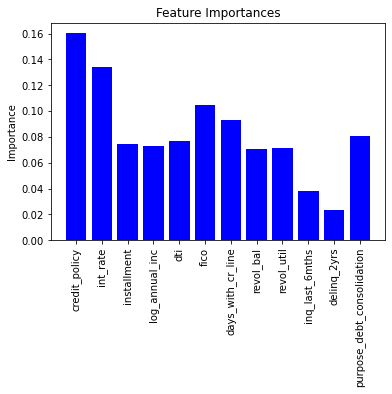

In [225]:
# Get the feature importances from Random Forest
importances = rf.feature_importances_
feature_names = X_train_sm.columns
plt.bar(range(len(importances)), importances, color='b')
plt.xticks(range(len(importances)), feature_names, rotation=90)
plt.ylabel('Importance')
plt.title('Feature Importances')

# Show the plot
plt.show()

#### 2.3 Logistic Regression

In [51]:
# Select only numerical columns in the training and test sets
numerical_columns = ['int_rate', 'installment', 'log_annual_inc', 'dti',
       'fico', 'days_with_cr_line', 'revol_bal', 'revol_util',
       'inq_last_6mths','delinq_2yrs']
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = X_train_sm.copy()  # Tạo một bản sao của DataFrame để tránh làm thay đổi dữ liệu gốc
X_train_scaled[numerical_columns] = scaler.fit_transform(X_train_scaled[numerical_columns])

# Transform the test data using the same scaler
X_test_scaled = X_test.copy()  # Tạo một bản sao của DataFrame để tránh làm thay đổi dữ liệu gốc
X_test_scaled[numerical_columns] = scaler.transform(X_test_scaled[numerical_columns])


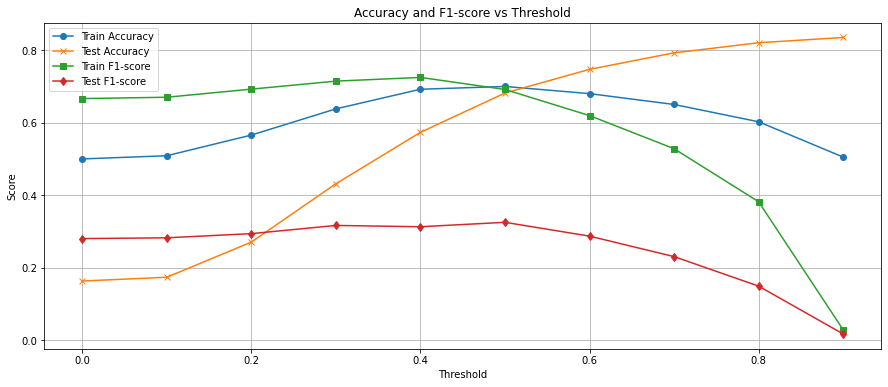

In [227]:
# Initialize lists to store results
thresholds = np.arange(0, 1, 0.1)  # Thresholds from 0.1 to 0.9
train_accuracies = []
test_accuracies = []
train_f1_scores = []
test_f1_scores = []

# Iterate through thresholds
for threshold in thresholds:
    # Initialize and train the Logistic Regression model with the threshold
    model = LogisticRegression(solver='saga')
    model.fit(X_train_scaled, y_train_sm)
    
    # Predict the probability of belonging to the positive class
    train_probs = model.predict_proba(X_train_scaled)[:, 1]
    test_probs = model.predict_proba(X_test_scaled)[:, 1]
    
    # Convert predictions based on the threshold
    train_preds = (train_probs > threshold).astype(int)
    test_preds = (test_probs > threshold).astype(int)
    
    # Calculate accuracy and F1-score for the train and test sets
    train_accuracy = accuracy_score(y_train_sm, train_preds)
    test_accuracy = accuracy_score(y_test, test_preds)
    train_f1 = f1_score(y_train_sm, train_preds)
    test_f1 = f1_score(y_test, test_preds)
    
    # Save results to the lists
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)
    train_f1_scores.append(train_f1)
    test_f1_scores.append(test_f1)

# Plot the results
plt.figure(figsize=(15, 6))

# Plot train and test accuracies
plt.plot(thresholds, train_accuracies, marker='o', label='Train Accuracy')
plt.plot(thresholds, test_accuracies, marker='x', label='Test Accuracy')

# Plot train and test F1-scores
plt.plot(thresholds, train_f1_scores, marker='s', label='Train F1-score')
plt.plot(thresholds, test_f1_scores, marker='d', label='Test F1-score')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Accuracy and F1-score vs Threshold')
plt.legend()
plt.grid(True)
plt.show()


In [123]:
import numpy as np
from sklearn.metrics import roc_auc_score

# Define the range of C values
C_values = np.logspace(-3, 5, 9)

# Lists to store AUC scores
auc_scores_train = []
auc_scores_test = []

# Iterate over each value of C
for C in C_values:
    # Create a logistic regression model with the current C value
    lr = LogisticRegression(C=C, max_iter=1000, solver='saga')
    
    # Train the model
    lr.fit(X_train_scaled, y_train_sm)
    
    # Predict probabilities for train set
    y_pred_proba_train = lr.predict_proba(X_train_scaled)[:, 1]
    
    # Predict probabilities for test set
    y_pred_proba_test = lr.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate AUC score for train set
    auc_train = roc_auc_score(y_train_sm, y_pred_proba_train)
    auc_scores_train.append(auc_train)
    
    # Calculate AUC score for test set
    auc_test = roc_auc_score(y_test, y_pred_proba_test)
    auc_scores_test.append(auc_test)

print("AUC scores for train and test sets:")
for C, train_auc, test_auc in zip(C_values, auc_scores_train, auc_scores_test):
    print(f"C = {C}: Train AUC = {train_auc}, Test AUC = {test_auc}")



AUC scores for train and test sets:
C = 0.001: Train AUC = 0.74142285688606, Test AUC = 0.616991175906388
C = 0.01: Train AUC = 0.7468102168035854, Test AUC = 0.6255124297518312
C = 0.1: Train AUC = 0.7583178684182729, Test AUC = 0.6328969243557772
C = 1.0: Train AUC = 0.7664089559948778, Test AUC = 0.6294768776065534
C = 10.0: Train AUC = 0.767737202225237, Test AUC = 0.6262886231714162
C = 100.0: Train AUC = 0.7678366414377664, Test AUC = 0.6256971531285745
C = 1000.0: Train AUC = 0.767848937684477, Test AUC = 0.6256287699554532
C = 10000.0: Train AUC = 0.767850667335549, Test AUC = 0.6256145604649346
C = 100000.0: Train AUC = 0.7678495666485032, Test AUC = 0.6256074557196751


In [87]:
# Logistic Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
    'max_iter': [100, 200, 300]
}

lr = LogisticRegression()
find_best_params("Logistic Regression", lr, param_grid_lr, X_train_scaled, y_train_sm, X_test_scaled, y_test)

# Các siêu tham số tối ưu cho Logistic Regression : {'C': 100, 'max_iter': 100, 'penalty': 'l2', 'solver': 'saga'}

### 3. Compare models

In [51]:
# Import data
df=pd.read_csv('loan_data.csv')

# Change the sign. in column names with
df.columns = [c.replace(".","_") for c in df.columns]
print(f"Số lượng bản ghi: {df.shape[0]}")
print(f"Số lượng thuộc tính: {df.shape[1]}")
df.sample(5)

# Pre-processing
df=pd.get_dummies(data=df)

to_log = ['revol_bal']
df= log_transform(df, to_log)

X = df.drop(columns=['not_fully_paid'])  
y = df['not_fully_paid']  

X = X[['credit_policy','int_rate', 'installment', 'log_annual_inc', 'dti','fico',
 'days_with_cr_line', 'revol_bal', 'revol_util','inq_last_6mths','delinq_2yrs','purpose_debt_consolidation']]

Số lượng bản ghi: 9578
Số lượng thuộc tính: 14


In [70]:
# Define models
models = [
    ('Decision Tree', DecisionTreeClassifier(max_depth=14, min_samples_leaf=1, min_samples_split=2, random_state=42)),
    ('Random Forest', RandomForestClassifier(n_estimators=50, max_depth=12, min_samples_split=2, random_state=42)),
    ('Logistic Regression', Pipeline([
        ('preprocessor', ColumnTransformer(
            transformers=[
                ('num', MinMaxScaler(), ['int_rate', 'installment', 'log_annual_inc', 'dti', 
                                         'fico', 'days_with_cr_line', 'revol_bal', 'revol_util', 
                                         'inq_last_6mths', 'delinq_2yrs'])
            ],
            remainder='passthrough')),
        ('classifier', LogisticRegression(solver='saga', C=100, penalty='l2', max_iter=100, random_state=42))
    ]))
]

In [71]:
# Dict to store result of each model
results = {i[0]:{} for i in models}
results

{'Decision Tree': {}, 'Random Forest': {}, 'Logistic Regression': {}}

In [72]:
# Initialize metric_records with empty dictionaries for each model
metric_records = {i[0]: {} for i in models}

# Iterate over each model and test size
# List of test sizes to try
test_sizes = [0.1, 0.2, 0.3, 0.4, 0.5]
for name, _ in models:
    for test_size in test_sizes:
        # Initialize dictionaries for train and test datasets
        metric_records[name][f'test_size_{test_size}_train'] = {}
        metric_records[name][f'test_size_{test_size}_test'] = {}

In [73]:
def evaluate_performance(name, model, test_size):
    def evaluate_dataset(dataset):
        print(f'Evaluate {dataset} set')

        y_pred = results[name][f'test_size_{test_size}'][f'y_{dataset}_pred']
        y_prob = results[name][f'test_size_{test_size}'][f'y_{dataset}_prob']
        y_score = y_prob[:, 1]  # Probability of positive label

        if dataset == 'train':
            y_true = y_train_sm
        else:
            y_true = y_test

        # AUC
        fpr, tpr, thresholds = metrics.roc_curve(y_true, y_score, pos_label=1)
        auc_score = metrics.auc(fpr, tpr)
        print('\tAUC:', auc_score)
        
         # Store fpr and tpr in metric_records
        metric_records[name][f'test_size_{test_size}_{dataset}']['fpr'] = fpr
        metric_records[name][f'test_size_{test_size}_{dataset}']['tpr'] = tpr
        metric_records[name][f'test_size_{test_size}_{dataset}']['auc'] = auc_score
        
        # Accuracy
        accuracy = metrics.accuracy_score(y_true, y_pred)
        print('\tAccuracy:', accuracy)

        # Precision, Recall, F1-score
        precision, recall, f1, _ = metrics.precision_recall_fscore_support(y_true, y_pred, average='binary')
        print('\tPrecision:', precision)
        print('\tRecall:', recall)
        print('\tF1-score:', f1)

        # ROC
        fig, axs = plt.subplots(1, 3, figsize=(15, 5))
        metrics.RocCurveDisplay.from_predictions(y_true, y_score, name=name, ax=axs[0])
        axs[0].set_title('ROC binary classification')

        # PRC
        metrics.PrecisionRecallDisplay.from_predictions(y_true, y_score, name=name, ax=axs[1])
        axs[1].set_title("Precision-Recall curve")
        axs[1].legend(loc='best')

        # PDF
        sns.histplot(y_prob, ax=axs[2], kde=True, stat='density', common_norm=True, bins=10)
        axs[2].set_title("Probability Distribution of Label")
        plt.show()

        # Confusion matrix
        metrics.ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
        plt.show()

        # Classification report
        print('Classification Report with default threshold=0.5')
        print(metrics.classification_report(y_true, y_pred))

        # Store metrics
        metric_records[name][f'{dataset}_auc'] = auc_score
        metric_records[name][f'{dataset}_accuracy'] = accuracy
        metric_records[name][f'{dataset}_precision'] = precision
        metric_records[name][f'{dataset}_recall'] = recall
        metric_records[name][f'{dataset}_f1'] = f1

    print('======================')
    print(f'Performance of {name} (Test Size: {test_size})\n')
    evaluate_dataset('train')
    evaluate_dataset('test')
    print('\n\n')

Test Size: 0.1
Decision Tree 0:00:00.120762
Cross-validation scores: [0.62097612 0.76843198 0.77223953 0.76393216 0.78878116]
Mean CV score: 0.7428721897655546
Performance of Decision Tree (Test Size: 0.1)

Performance of Decision Tree (Test Size: 0.1)

Evaluate train set
	AUC: 0.9592992418853711
	Accuracy: 0.8832733314871227
	Precision: 0.8701524471783899
	Recall: 0.9009969537524232
	F1-score: 0.8853061224489797


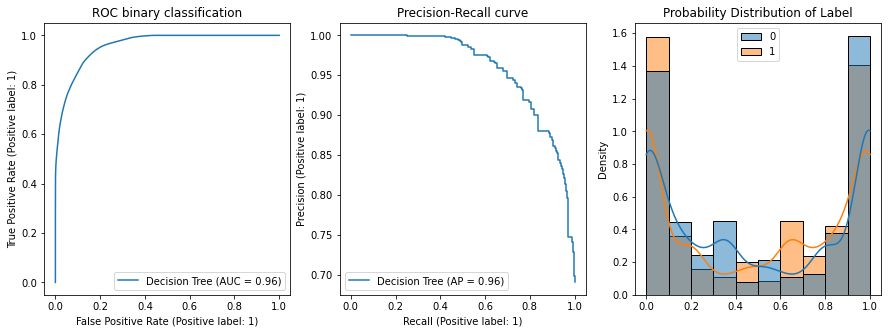

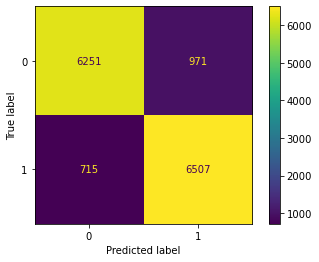

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      7222
           1       0.87      0.90      0.89      7222

    accuracy                           0.88     14444
   macro avg       0.88      0.88      0.88     14444
weighted avg       0.88      0.88      0.88     14444

Evaluate test set
	AUC: 0.5805994329688133
	Accuracy: 0.6878914405010439
	Precision: 0.19852941176470587
	Recall: 0.4
	F1-score: 0.26535626535626533


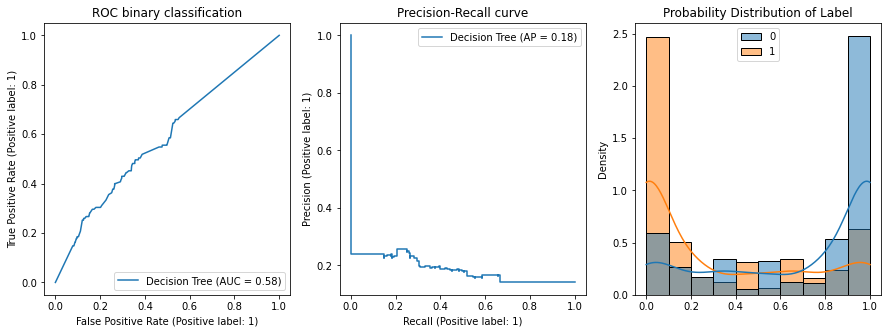

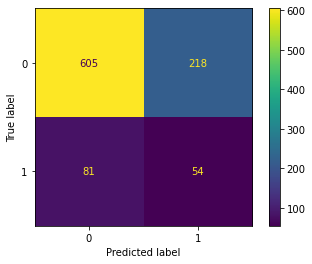

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.88      0.74      0.80       823
           1       0.20      0.40      0.27       135

    accuracy                           0.69       958
   macro avg       0.54      0.57      0.53       958
weighted avg       0.79      0.69      0.73       958







Random Forest 0:00:01.179855
Cross-validation scores: [0.62651436 0.83419868 0.82450675 0.81758394 0.82756233]
Mean CV score: 0.7860732130375128
Performance of Random Forest (Test Size: 0.1)

Performance of Random Forest (Test Size: 0.1)

Evaluate train set
	AUC: 0.9585835987932194
	Accuracy: 0.8823733037939628
	Precision: 0.8661010208139998
	Recall: 0.9045970645250623
	F1-score: 0.8849305790721301


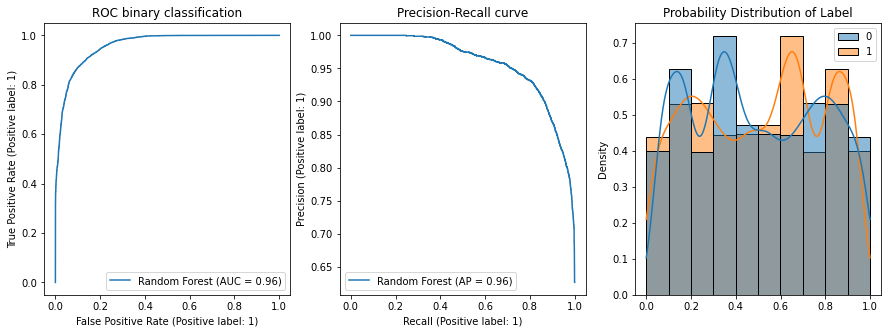

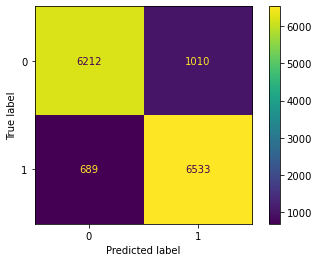

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.90      0.86      0.88      7222
           1       0.87      0.90      0.88      7222

    accuracy                           0.88     14444
   macro avg       0.88      0.88      0.88     14444
weighted avg       0.88      0.88      0.88     14444

Evaluate test set
	AUC: 0.6680617433958868
	Accuracy: 0.721294363256785
	Precision: 0.22950819672131148
	Recall: 0.4148148148148148
	F1-score: 0.2955145118733509


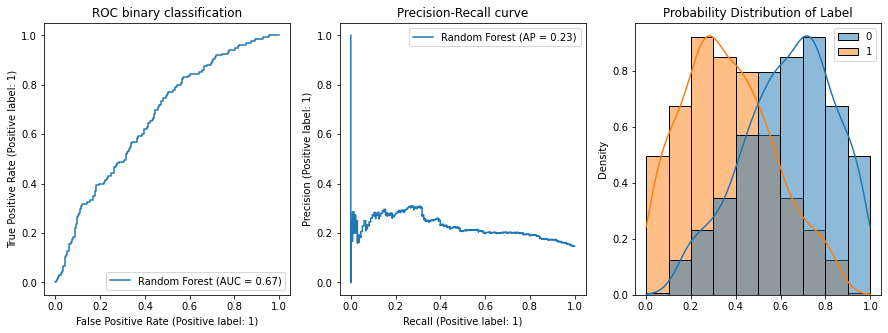

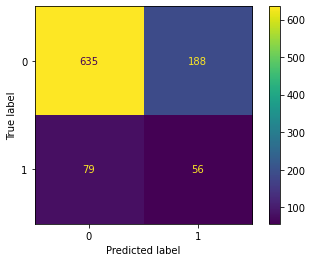

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.89      0.77      0.83       823
           1       0.23      0.41      0.30       135

    accuracy                           0.72       958
   macro avg       0.56      0.59      0.56       958
weighted avg       0.80      0.72      0.75       958







Logistic Regression 0:00:00.077288
Cross-validation scores: [0.58878505 0.72135687 0.71824161 0.72101073 0.72576177]
Mean CV score: 0.6950312053840675
Performance of Logistic Regression (Test Size: 0.1)

Performance of Logistic Regression (Test Size: 0.1)

Evaluate train set
	AUC: 0.7708872264130932
	Accuracy: 0.7002215452783163
	Precision: 0.7089595375722544
	Recall: 0.6793132096372196
	F1-score: 0.6938198274642908


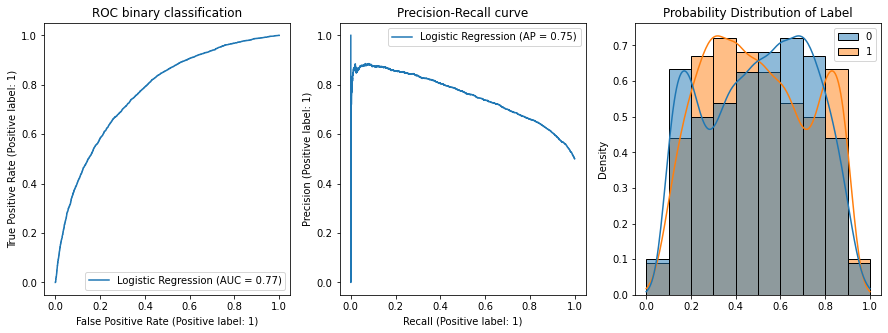

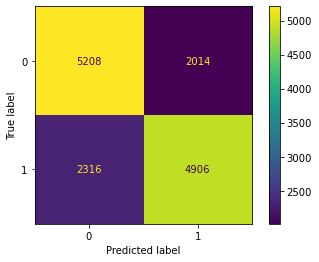

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.69      0.72      0.71      7222
           1       0.71      0.68      0.69      7222

    accuracy                           0.70     14444
   macro avg       0.70      0.70      0.70     14444
weighted avg       0.70      0.70      0.70     14444

Evaluate test set
	AUC: 0.6415372845506503
	Accuracy: 0.6691022964509394
	Precision: 0.2191358024691358
	Recall: 0.5259259259259259
	F1-score: 0.3093681917211329


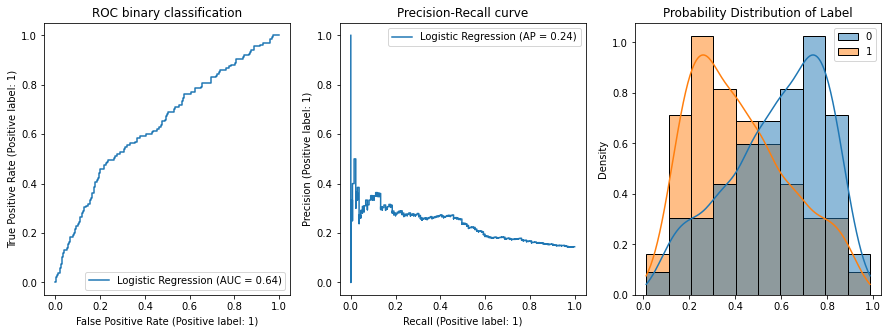

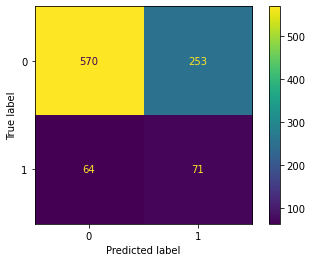

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.90      0.69      0.78       823
           1       0.22      0.53      0.31       135

    accuracy                           0.67       958
   macro avg       0.56      0.61      0.55       958
weighted avg       0.80      0.67      0.72       958







Test Size: 0.2
Decision Tree 0:00:00.109939
Cross-validation scores: [0.62742813 0.76068376 0.76573427 0.75514963 0.7609794 ]
Mean CV score: 0.7339950372208437
Performance of Decision Tree (Test Size: 0.2)

Performance of Decision Tree (Test Size: 0.2)

Evaluate train set
	AUC: 0.9679878103280395
	Accuracy: 0.8953994404724899
	Precision: 0.8830171635049684
	Recall: 0.91156356854212
	F1-score: 0.8970633221168552


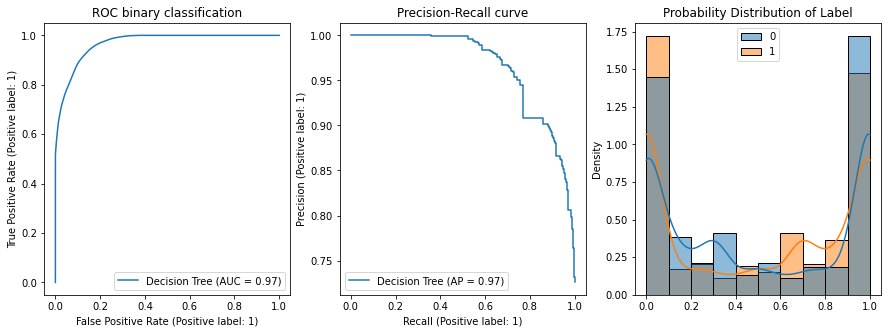

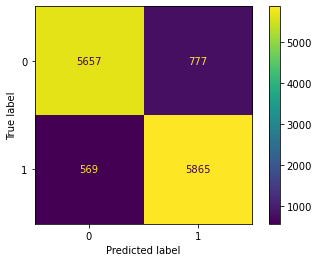

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      6434
           1       0.88      0.91      0.90      6434

    accuracy                           0.90     12868
   macro avg       0.90      0.90      0.90     12868
weighted avg       0.90      0.90      0.90     12868

Evaluate test set
	AUC: 0.5535590357277326
	Accuracy: 0.6591858037578288
	Precision: 0.1881720430107527
	Recall: 0.3442622950819672
	F1-score: 0.24333719582850522


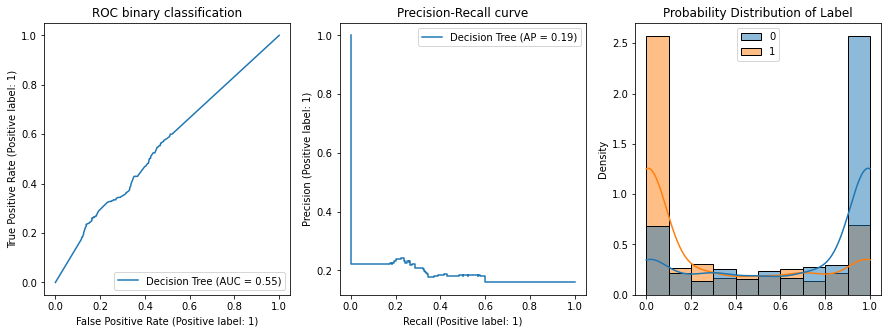

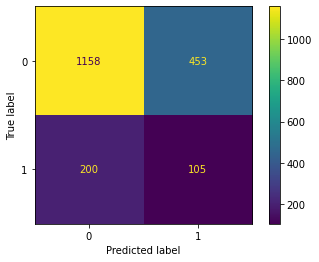

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.85      0.72      0.78      1611
           1       0.19      0.34      0.24       305

    accuracy                           0.66      1916
   macro avg       0.52      0.53      0.51      1916
weighted avg       0.75      0.66      0.69      1916







Random Forest 0:00:01.064705
Cross-validation scores: [0.63597514 0.82983683 0.82090132 0.81733385 0.82782744]
Mean CV score: 0.7863749154071734
Performance of Random Forest (Test Size: 0.2)

Performance of Random Forest (Test Size: 0.2)

Evaluate train set
	AUC: 0.9630752523241418
	Accuracy: 0.8882499222878458
	Precision: 0.8695266272189349
	Recall: 0.9135840845508237
	F1-score: 0.891011065635895


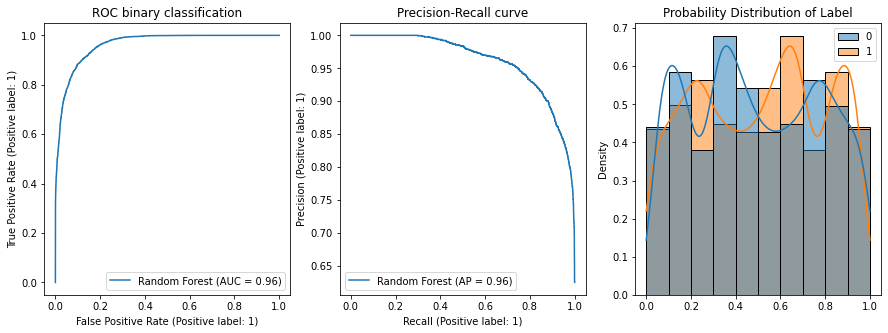

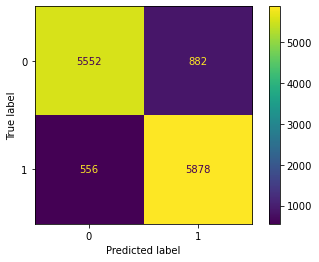

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.91      0.86      0.89      6434
           1       0.87      0.91      0.89      6434

    accuracy                           0.89     12868
   macro avg       0.89      0.89      0.89     12868
weighted avg       0.89      0.89      0.89     12868

Evaluate test set
	AUC: 0.6525770573210815
	Accuracy: 0.7244258872651357
	Precision: 0.2549450549450549
	Recall: 0.380327868852459
	F1-score: 0.30526315789473685


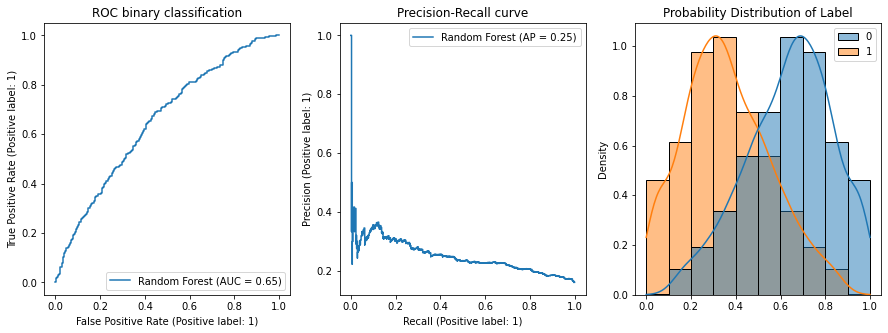

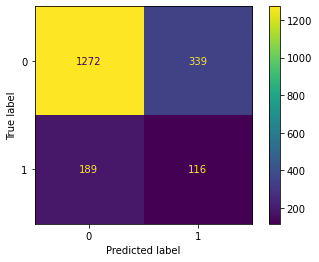

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1611
           1       0.25      0.38      0.31       305

    accuracy                           0.72      1916
   macro avg       0.56      0.58      0.57      1916
weighted avg       0.77      0.72      0.74      1916







Logistic Regression 0:00:00.052607
Cross-validation scores: [0.59090909 0.71833722 0.72066822 0.70773416 0.71628449]
Mean CV score: 0.6907866370361513
Performance of Logistic Regression (Test Size: 0.2)

Performance of Logistic Regression (Test Size: 0.2)

Evaluate train set
	AUC: 0.7660521133792549
	Accuracy: 0.6946689462231893
	Precision: 0.7038906071951815
	Recall: 0.6720547093565433
	F1-score: 0.6876043571598951


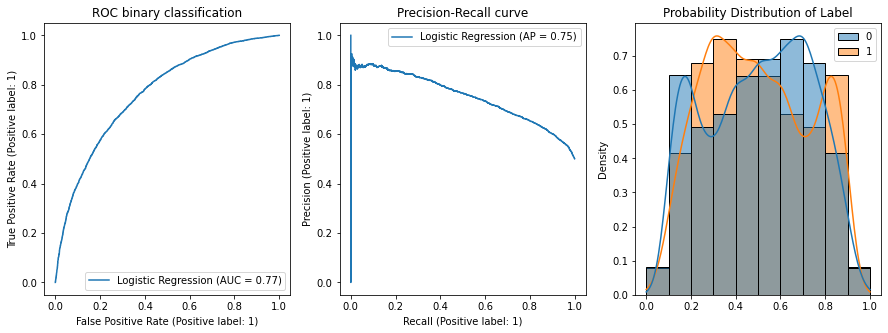

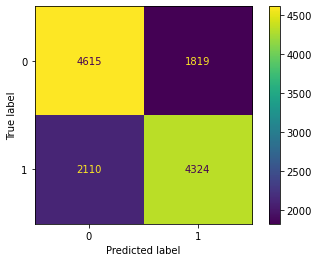

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.69      0.72      0.70      6434
           1       0.70      0.67      0.69      6434

    accuracy                           0.69     12868
   macro avg       0.70      0.69      0.69     12868
weighted avg       0.70      0.69      0.69     12868

Evaluate test set
	AUC: 0.6478432090850811
	Accuracy: 0.6847599164926931
	Precision: 0.26003210272873195
	Recall: 0.5311475409836065
	F1-score: 0.34913793103448276


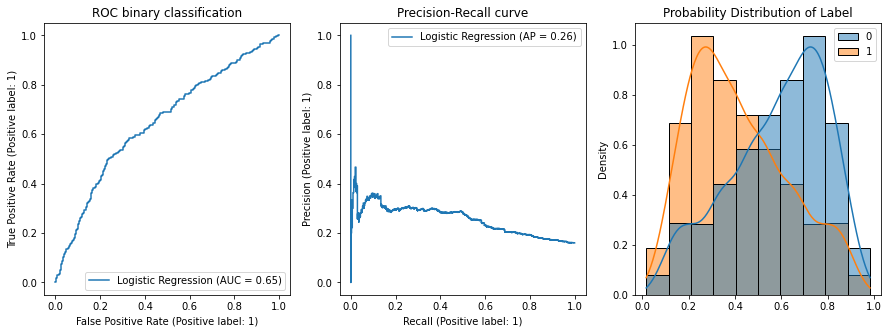

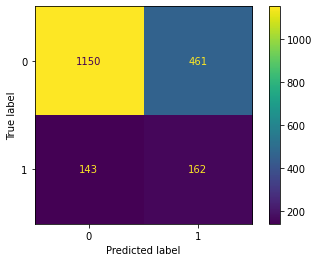

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.89      0.71      0.79      1611
           1       0.26      0.53      0.35       305

    accuracy                           0.68      1916
   macro avg       0.57      0.62      0.57      1916
weighted avg       0.79      0.68      0.72      1916







Test Size: 0.3
Decision Tree 0:00:00.093266
Cross-validation scores: [0.60354767 0.76895787 0.75964523 0.77694013 0.7635315 ]
Mean CV score: 0.7345244817294507
Performance of Decision Tree (Test Size: 0.3)

Performance of Decision Tree (Test Size: 0.3)

Evaluate train set
	AUC: 0.9676768955615205
	Accuracy: 0.900833776831648
	Precision: 0.8704705689457288
	Recall: 0.9418130211105198
	F1-score: 0.904737559645535


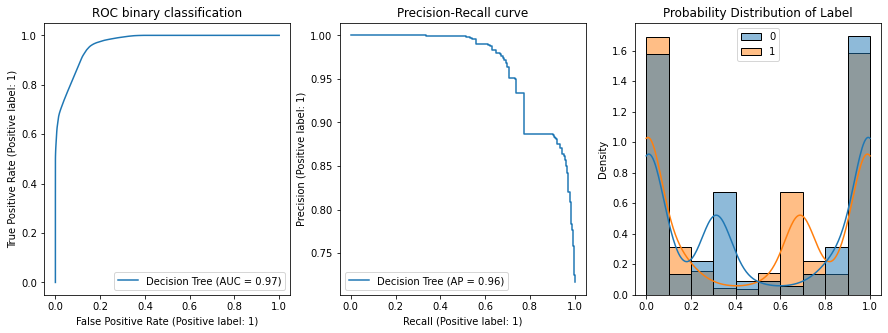

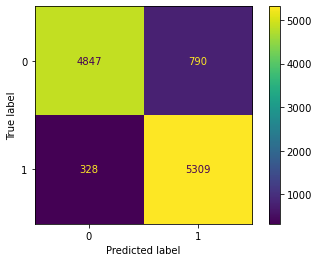

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.94      0.86      0.90      5637
           1       0.87      0.94      0.90      5637

    accuracy                           0.90     11274
   macro avg       0.90      0.90      0.90     11274
weighted avg       0.90      0.90      0.90     11274

Evaluate test set
	AUC: 0.5651881959990304
	Accuracy: 0.6475295755045233
	Precision: 0.20935175345377258
	Recall: 0.4227467811158798
	F1-score: 0.2800284292821606


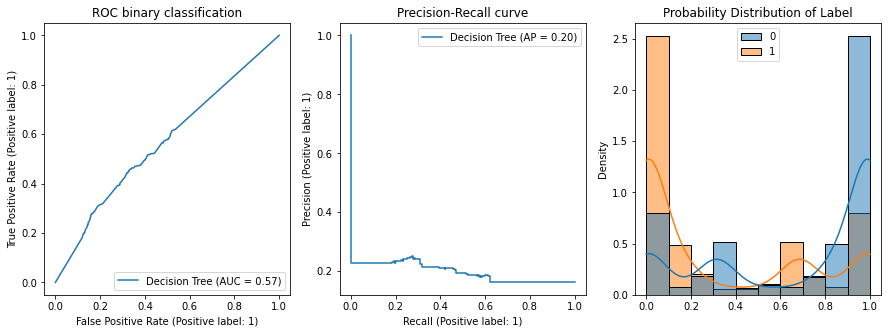

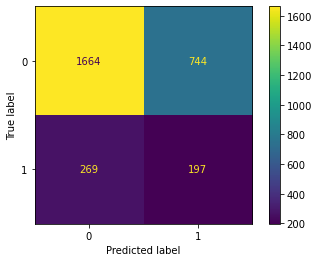

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.86      0.69      0.77      2408
           1       0.21      0.42      0.28       466

    accuracy                           0.65      2874
   macro avg       0.54      0.56      0.52      2874
weighted avg       0.76      0.65      0.69      2874







Random Forest 0:00:00.950239
Cross-validation scores: [0.64168514 0.82394678 0.81596452 0.83769401 0.83762201]
Mean CV score: 0.7913824941911595
Performance of Random Forest (Test Size: 0.3)

Performance of Random Forest (Test Size: 0.3)

Evaluate train set
	AUC: 0.9679969979640777
	Accuracy: 0.9019868724498847
	Precision: 0.885899182561308
	Recall: 0.9228312932410857
	F1-score: 0.9039881831610045


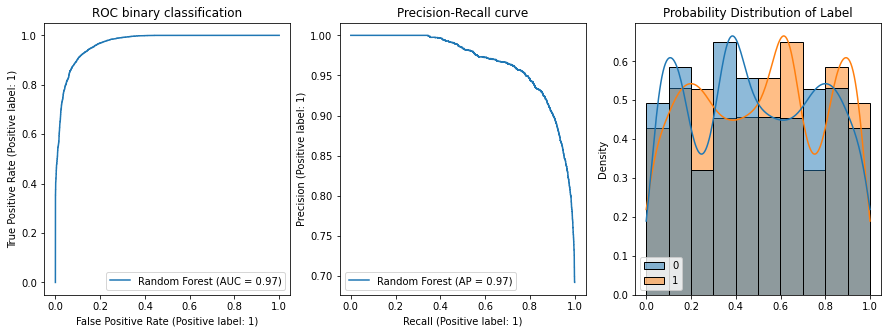

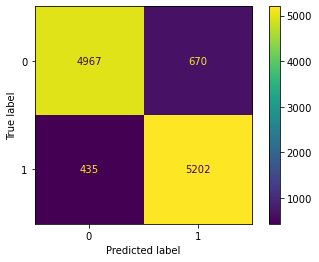

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.92      0.88      0.90      5637
           1       0.89      0.92      0.90      5637

    accuracy                           0.90     11274
   macro avg       0.90      0.90      0.90     11274
weighted avg       0.90      0.90      0.90     11274

Evaluate test set
	AUC: 0.6406158655697032
	Accuracy: 0.7171189979123174
	Precision: 0.2503597122302158
	Recall: 0.37339055793991416
	F1-score: 0.2997416020671834


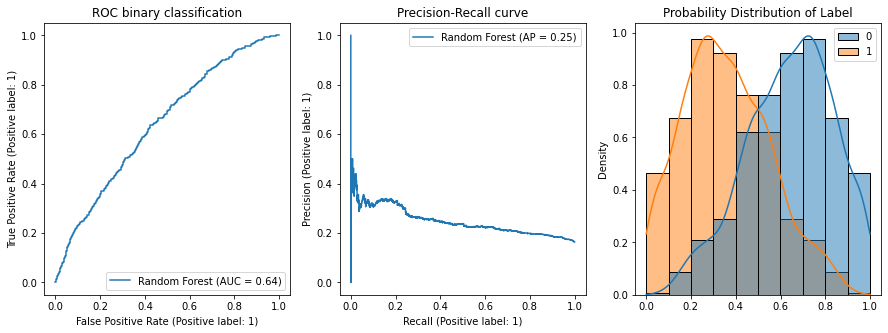

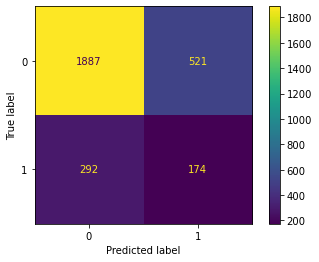

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.87      0.78      0.82      2408
           1       0.25      0.37      0.30       466

    accuracy                           0.72      2874
   macro avg       0.56      0.58      0.56      2874
weighted avg       0.77      0.72      0.74      2874







Logistic Regression 0:00:00.063168
Cross-validation scores: [0.57827051 0.71840355 0.70953437 0.7113082  0.73380657]
Mean CV score: 0.690264639163291
Performance of Logistic Regression (Test Size: 0.3)

Performance of Logistic Regression (Test Size: 0.3)

Evaluate train set
	AUC: 0.7671328741091994
	Accuracy: 0.694252261841405
	Precision: 0.7034559643255296
	Recall: 0.6716338477913784
	F1-score: 0.6871766947998912


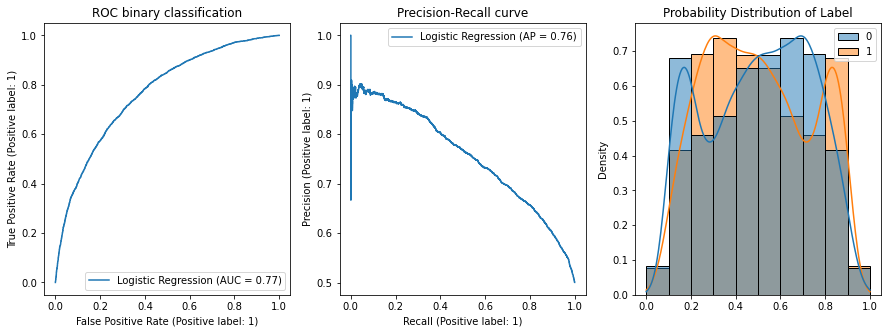

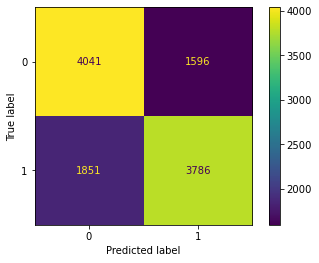

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.69      0.72      0.70      5637
           1       0.70      0.67      0.69      5637

    accuracy                           0.69     11274
   macro avg       0.69      0.69      0.69     11274
weighted avg       0.69      0.69      0.69     11274

Evaluate test set
	AUC: 0.6355504897836967
	Accuracy: 0.6802366040361865
	Precision: 0.2513721185510428
	Recall: 0.49141630901287553
	F1-score: 0.33260711692084244


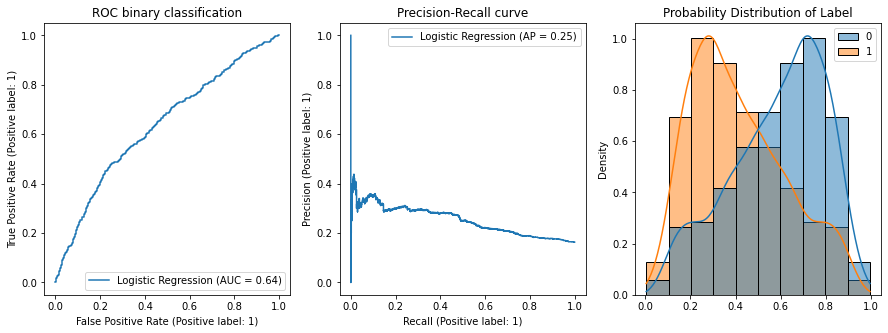

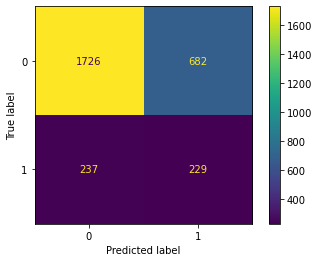

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.88      0.72      0.79      2408
           1       0.25      0.49      0.33       466

    accuracy                           0.68      2874
   macro avg       0.57      0.60      0.56      2874
weighted avg       0.78      0.68      0.72      2874







Test Size: 0.4
Decision Tree 0:00:00.179831
Cross-validation scores: [0.62344398 0.76400415 0.77489627 0.75259336 0.76607884]
Mean CV score: 0.7362033195020746
Performance of Decision Tree (Test Size: 0.4)

Performance of Decision Tree (Test Size: 0.4)

Evaluate train set
	AUC: 0.9576083185551212
	Accuracy: 0.8776970954356846
	Precision: 0.8563319632021922
	Recall: 0.9076763485477178
	F1-score: 0.881256924161547


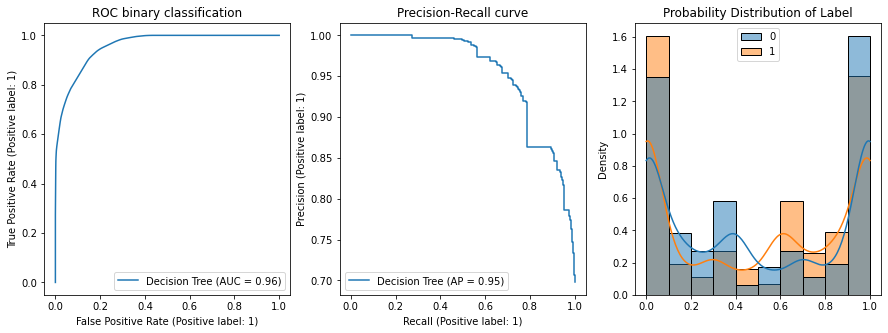

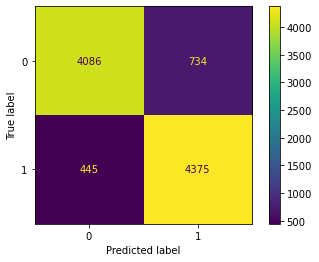

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.90      0.85      0.87      4820
           1       0.86      0.91      0.88      4820

    accuracy                           0.88      9640
   macro avg       0.88      0.88      0.88      9640
weighted avg       0.88      0.88      0.88      9640

Evaluate test set
	AUC: 0.5669126342541154
	Accuracy: 0.6484864300626305
	Precision: 0.20681458003169573
	Recall: 0.4299835255354201
	F1-score: 0.27929373996789725


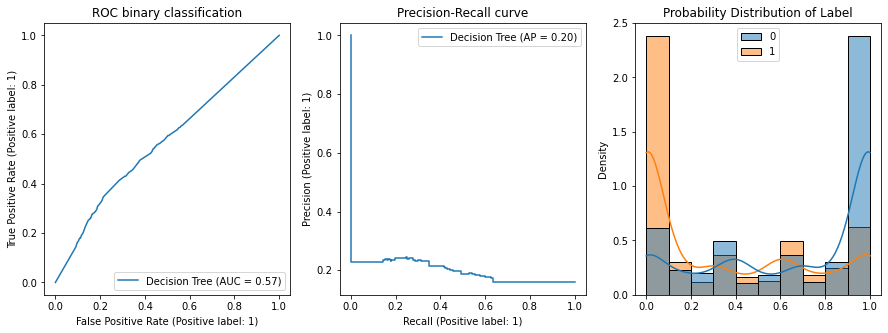

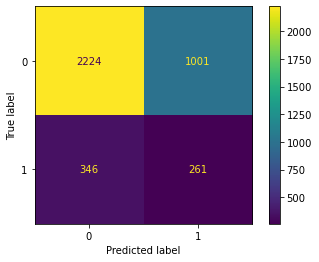

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.87      0.69      0.77      3225
           1       0.21      0.43      0.28       607

    accuracy                           0.65      3832
   macro avg       0.54      0.56      0.52      3832
weighted avg       0.76      0.65      0.69      3832







Random Forest 0:00:01.122291
Cross-validation scores: [0.62603734 0.83298755 0.8246888  0.8246888  0.84232365]
Mean CV score: 0.7901452282157677
Performance of Random Forest (Test Size: 0.4)

Performance of Random Forest (Test Size: 0.4)

Evaluate train set
	AUC: 0.9723627348013981
	Accuracy: 0.9069502074688797
	Precision: 0.8958627648839556
	Recall: 0.920954356846473
	F1-score: 0.908235294117647


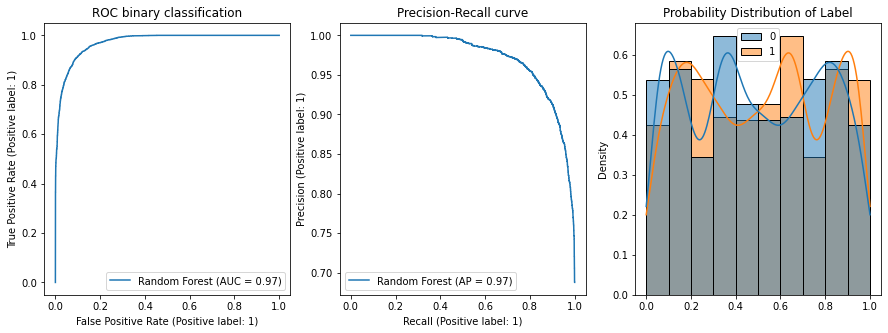

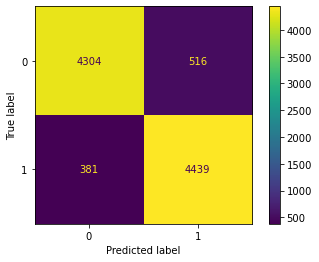

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.92      0.89      0.91      4820
           1       0.90      0.92      0.91      4820

    accuracy                           0.91      9640
   macro avg       0.91      0.91      0.91      9640
weighted avg       0.91      0.91      0.91      9640

Evaluate test set
	AUC: 0.6415636693357853
	Accuracy: 0.7192066805845512
	Precision: 0.2408839779005525
	Recall: 0.35914332784184516
	F1-score: 0.28835978835978837


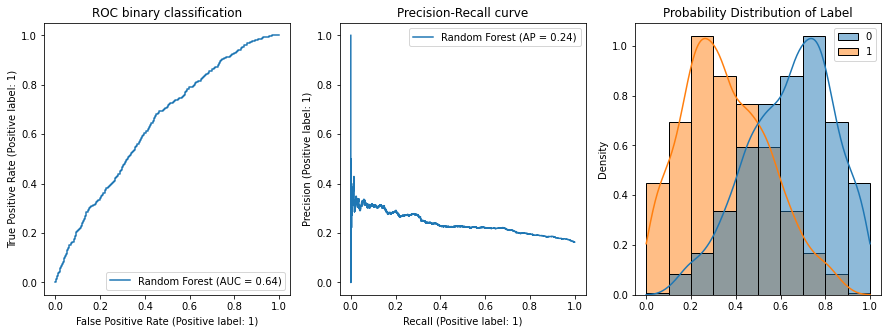

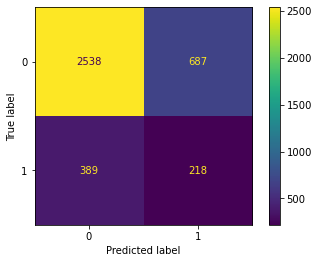

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.87      0.79      0.83      3225
           1       0.24      0.36      0.29       607

    accuracy                           0.72      3832
   macro avg       0.55      0.57      0.56      3832
weighted avg       0.77      0.72      0.74      3832







Logistic Regression 0:00:00.039284
Cross-validation scores: [0.5840249  0.71058091 0.71887967 0.7126556  0.73651452]
Mean CV score: 0.6925311203319502
Performance of Logistic Regression (Test Size: 0.4)

Performance of Logistic Regression (Test Size: 0.4)

Evaluate train set
	AUC: 0.7653716792066252
	Accuracy: 0.6966804979253112
	Precision: 0.7061765985210962
	Recall: 0.6736514522821577
	F1-score: 0.6895306859205776


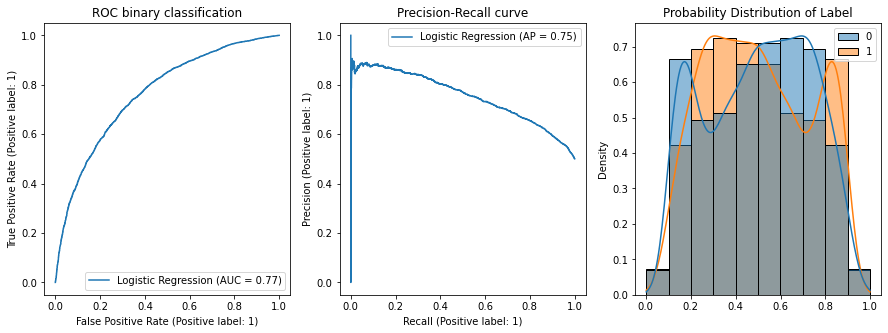

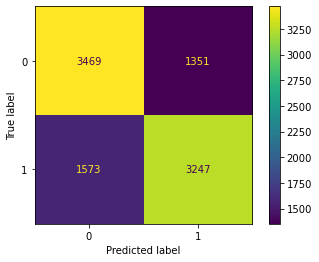

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.69      0.72      0.70      4820
           1       0.71      0.67      0.69      4820

    accuracy                           0.70      9640
   macro avg       0.70      0.70      0.70      9640
weighted avg       0.70      0.70      0.70      9640

Evaluate test set
	AUC: 0.6388209902558012
	Accuracy: 0.680062630480167
	Precision: 0.24775876120619397
	Recall: 0.500823723228995
	F1-score: 0.3315158124318429


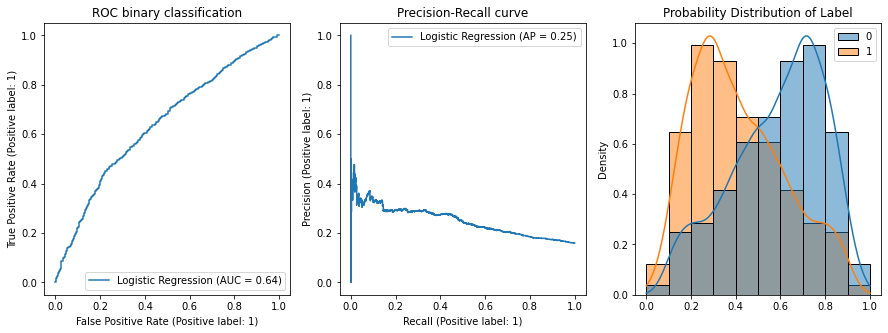

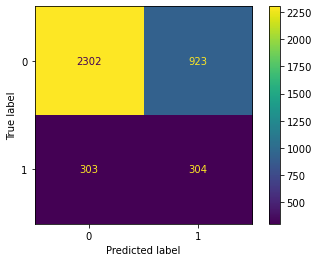

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.88      0.71      0.79      3225
           1       0.25      0.50      0.33       607

    accuracy                           0.68      3832
   macro avg       0.57      0.61      0.56      3832
weighted avg       0.78      0.68      0.72      3832







Test Size: 0.5
Decision Tree 0:00:00.062906
Cross-validation scores: [0.62103298 0.77784692 0.7728687  0.74922215 0.78331258]
Mean CV score: 0.7408566661577888
Performance of Decision Tree (Test Size: 0.5)

Performance of Decision Tree (Test Size: 0.5)

Evaluate train set
	AUC: 0.9697440037173356
	Accuracy: 0.8984316654219567
	Precision: 0.8777436865706868
	Recall: 0.925815285038586
	F1-score: 0.9011388417736855


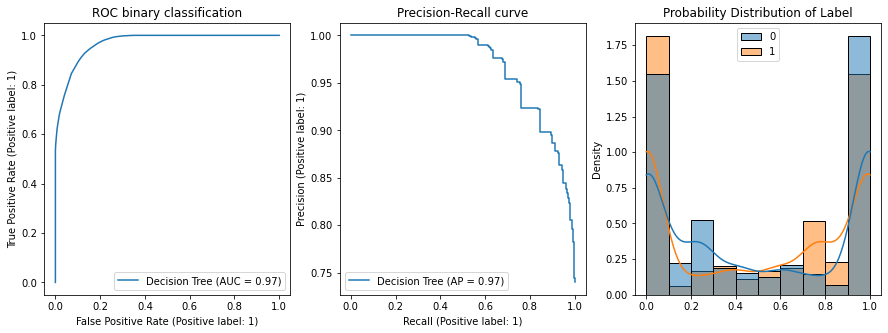

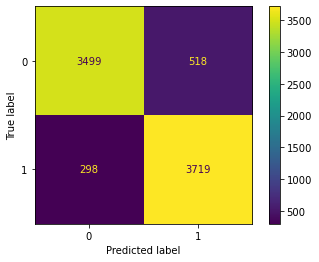

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.92      0.87      0.90      4017
           1       0.88      0.93      0.90      4017

    accuracy                           0.90      8034
   macro avg       0.90      0.90      0.90      8034
weighted avg       0.90      0.90      0.90      8034

Evaluate test set
	AUC: 0.5790082105941721
	Accuracy: 0.6656922113176028
	Precision: 0.22
	Recall: 0.4336399474375821
	F1-score: 0.291906236178682


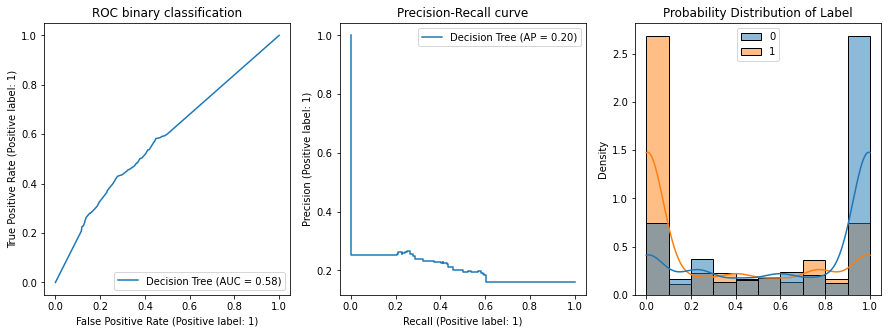

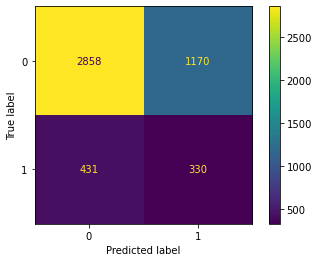

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.87      0.71      0.78      4028
           1       0.22      0.43      0.29       761

    accuracy                           0.67      4789
   macro avg       0.54      0.57      0.54      4789
weighted avg       0.77      0.67      0.70      4789







Random Forest 0:00:00.591483
Cross-validation scores: [0.63098942 0.83447418 0.80709396 0.82887368 0.84184309]
Mean CV score: 0.7886548653501455
Performance of Random Forest (Test Size: 0.5)

Performance of Random Forest (Test Size: 0.5)

Evaluate train set
	AUC: 0.9820438887776489
	Accuracy: 0.9210853871048046
	Precision: 0.9014953714692618
	Recall: 0.9454817027632562
	F1-score: 0.9229647630619684


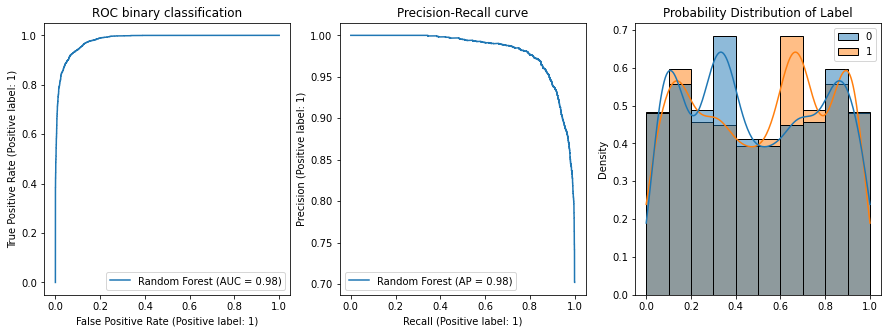

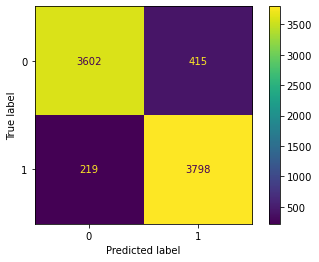

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      4017
           1       0.90      0.95      0.92      4017

    accuracy                           0.92      8034
   macro avg       0.92      0.92      0.92      8034
weighted avg       0.92      0.92      0.92      8034

Evaluate test set
	AUC: 0.643572195681478
	Accuracy: 0.7158070578408854
	Precision: 0.2391304347826087
	Recall: 0.36136662286465177
	F1-score: 0.28780743066457354


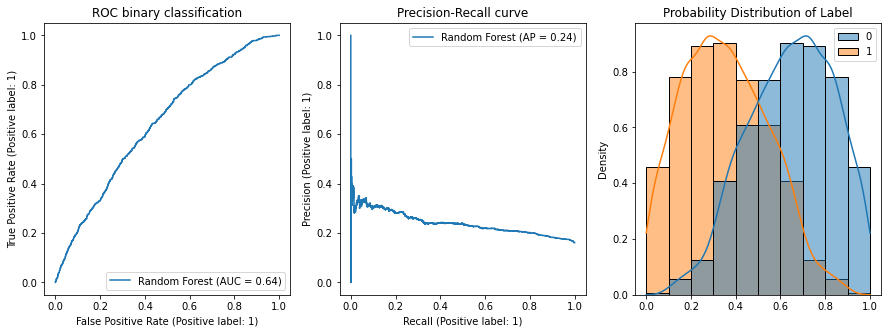

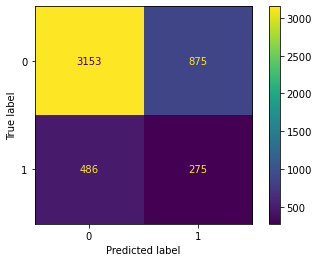

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.87      0.78      0.82      4028
           1       0.24      0.36      0.29       761

    accuracy                           0.72      4789
   macro avg       0.55      0.57      0.56      4789
weighted avg       0.77      0.72      0.74      4789







Logistic Regression 0:00:00.041466
Cross-validation scores: [0.58929683 0.71686372 0.70877411 0.71001867 0.74159402]
Mean CV score: 0.6933094703201513
Performance of Logistic Regression (Test Size: 0.5)

Performance of Logistic Regression (Test Size: 0.5)

Evaluate train set
	AUC: 0.7601698878843828
	Accuracy: 0.6967886482449589
	Precision: 0.7026403486285567
	Recall: 0.6823500124470998
	F1-score: 0.6923465521596361


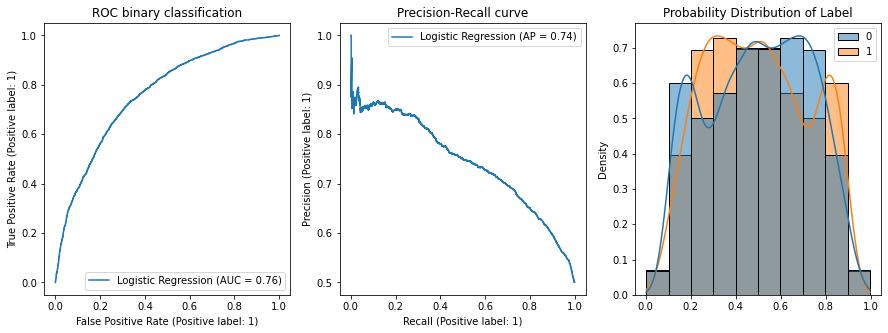

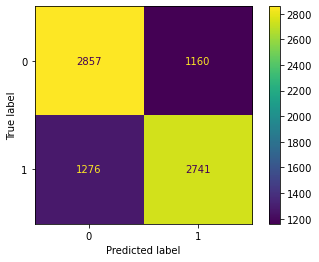

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.69      0.71      0.70      4017
           1       0.70      0.68      0.69      4017

    accuracy                           0.70      8034
   macro avg       0.70      0.70      0.70      8034
weighted avg       0.70      0.70      0.70      8034

Evaluate test set
	AUC: 0.6435128215500694
	Accuracy: 0.6765504280643141
	Precision: 0.24613402061855671
	Recall: 0.5019710906701709
	F1-score: 0.33030696065715526


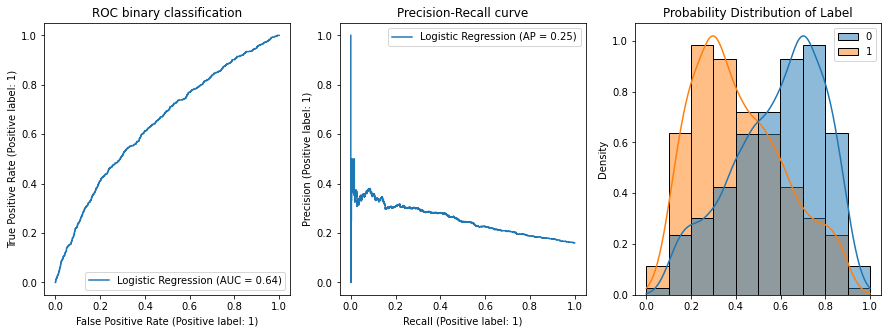

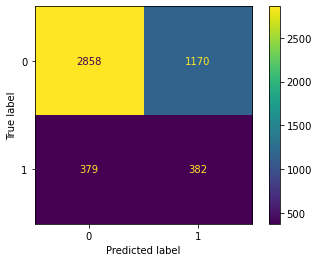

Classification Report with default threshold=0.5
              precision    recall  f1-score   support

           0       0.88      0.71      0.79      4028
           1       0.25      0.50      0.33       761

    accuracy                           0.68      4789
   macro avg       0.56      0.61      0.56      4789
weighted avg       0.78      0.68      0.71      4789









In [74]:
from sklearn.model_selection import cross_val_score

# Iterate over each test size
for test_size in test_sizes:
    print(f"Test Size: {test_size}")
    print("=====================================")
    
    # Split the data into train and test sets using the current test size
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    
    # Apply SMOTE to the training data only
    smote = SMOTE(random_state=42)
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

    # Train and evaluate the models
    for name, model in models:
        start = datetime.now()
        model.fit(X_train_sm, y_train_sm)
        print(name, datetime.now() - start)
        
        # Perform cross-validation
        cv_scores = cross_val_score(model, X_train_sm, y_train_sm, cv=5)
        print("Cross-validation scores:", cv_scores)
        print("Mean CV score:", np.mean(cv_scores))
        
        # Store results
        results[name][f'test_size_{test_size}'] = {}
        results[name][f'test_size_{test_size}']['cv_scores'] = cv_scores
        results[name][f'test_size_{test_size}']['mean_cv_score'] = np.mean(cv_scores)
        results[name][f'test_size_{test_size}']['y_train_pred'] = model.predict(X_train_sm)
        results[name][f'test_size_{test_size}']['y_train_prob'] = model.predict_proba(X_train_sm)
        results[name][f'test_size_{test_size}']['y_test_pred'] = model.predict(X_test)
        results[name][f'test_size_{test_size}']['y_test_prob'] = model.predict_proba(X_test)
        
        print('======================')
        print(f'Performance of {name} (Test Size: {test_size})\n')
        evaluate_performance(name, model, test_size)
        print('\n\n')

In [75]:
# List to store performance metrics
performance_metrics = []

# Iterate over each test size
for test_size in test_sizes:
    # Split the data into train and test sets using the current test size
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    
    # Apply SMOTE to the training data only
    smote = SMOTE(random_state=42)
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
    
    # Train and evaluate the models
    for name, model in models:
        model.fit(X_train_sm, y_train_sm)
        y_test_pred = model.predict(X_test)
        y_test_prob = model.predict_proba(X_test)[:, 1]
        
        test_auc = metrics.roc_auc_score(y_test, y_test_prob)
        test_accuracy = metrics.accuracy_score(y_test, y_test_pred)
        test_precision, test_recall, test_f1, _ = metrics.precision_recall_fscore_support(y_test, y_test_pred, average='binary')
        
        # Perform cross-validation
        cv_scores = cross_val_score(model, X_train_sm, y_train_sm, cv=5)
        mean_cv_score = np.mean(cv_scores)
        
        # Round the performance metrics to two decimal places
        test_auc = round(test_auc, 2)
        test_accuracy = round(test_accuracy, 2)
        test_precision = round(test_precision, 2)
        test_recall = round(test_recall, 2)
        test_f1 = round(test_f1, 2)
        mean_cv_score = round(mean_cv_score, 2)
        
        # Append rounded performance metrics to the list
        performance_metrics.append({
            'Test Size': test_size,
            'Model': name,
            'AUC': test_auc,
            'Accuracy': test_accuracy,
            'Precision': test_precision,
            'Recall': test_recall,
            'F1-score': test_f1,
            'Mean CV Score': mean_cv_score
        })

# Create DataFrame from the list of performance metrics
performance_df = pd.DataFrame(performance_metrics)

# Display the DataFrame
performance_df


,Test Size,Model,AUC,Accuracy,Precision,Recall,F1-score,Mean CV Score
0,0.1,Decision Tree,0.58,0.69,0.20,0.40,0.27,0.74
1,0.1,Random Forest,0.67,0.72,0.23,0.41,0.30,0.79
2,0.1,Logistic Regression,0.64,0.67,0.22,0.53,0.31,0.70
3,0.2,Decision Tree,0.55,0.66,0.19,0.34,0.24,0.73
4,0.2,Random Forest,0.65,0.72,0.25,0.38,0.31,0.79
5,0.2,Logistic Regression,0.65,0.68,0.26,0.53,0.35,0.69
6,0.3,Decision Tree,0.57,0.65,0.21,0.42,0.28,0.73
7,0.3,Random Forest,0.64,0.72,0.25,0.37,0.30,0.79
8,0.3,Logistic Regression,0.64,0.68,0.25,0.49,0.33,0.69
9,0.4,Decision Tree,0.57,0.65,0.21,0.43,0.28,0.74


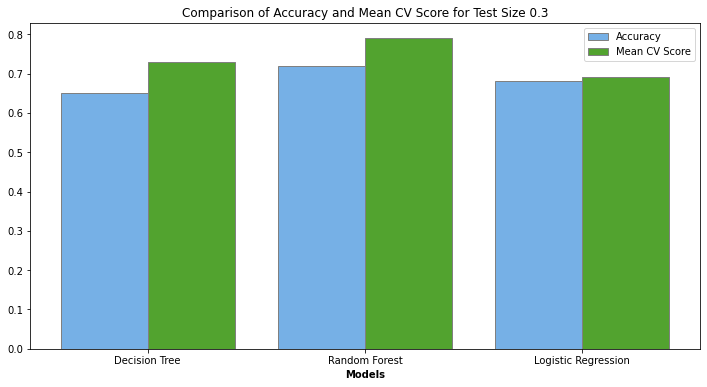

In [88]:
# Filter the DataFrame for test size 0.3
test_size_0_3_df = performance_df[performance_df['Test Size'] == 0.3]

plt.figure(figsize=(12, 6))
bar_width = 0.4
r1 = range(len(test_size_0_3_df))
r2 = [x + bar_width for x in r1]
plt.bar(r1, test_size_0_3_df['Accuracy'], color='#76b0e6', width=bar_width, edgecolor='grey', label='Accuracy')
plt.bar(r2, test_size_0_3_df['Mean CV Score'], color='#52a32f', width=bar_width, edgecolor='grey', label='Mean CV Score')
plt.xlabel('Models', fontweight='bold')
plt.xticks([r + bar_width/2 for r in range(len(test_size_0_3_df))], test_size_0_3_df['Model'])
plt.legend()
plt.title('Comparison of Accuracy and Mean CV Score for Test Size 0.3')
plt.show()

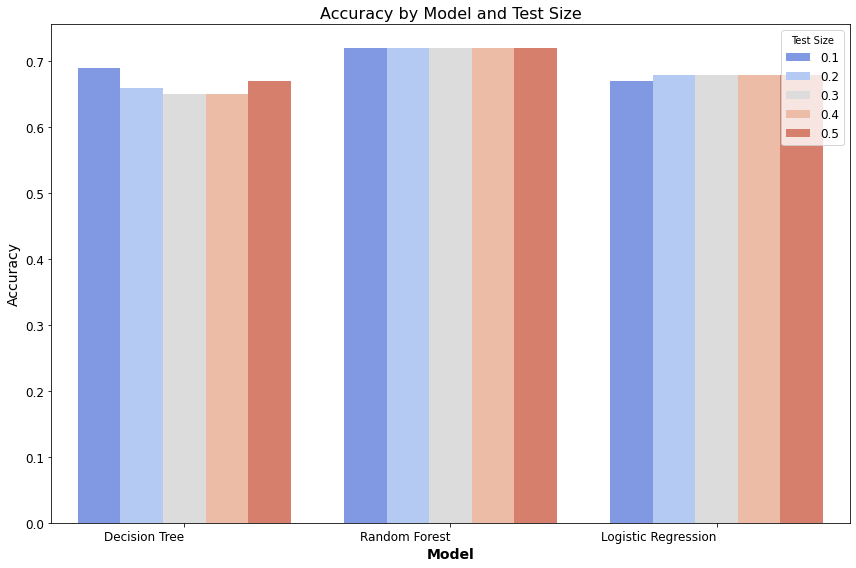

In [89]:
# Plot the bar chart with 'coolwarm' colormap
plt.figure(figsize=(12, 8))
sns.barplot(x='Model', y='Accuracy', hue='Test Size', data=performance_df, ci=None, palette='coolwarm')
plt.title('Accuracy by Model and Test Size', fontsize=16)
plt.xlabel('Model', fontsize=14, fontweight='bold') 
plt.ylabel('Accuracy', fontsize=14)
plt.xticks(ha='right', fontsize=12)
plt.yticks(fontsize=12)  
plt.legend(title='Test Size', fontsize=12)
plt.tight_layout()
plt.show()


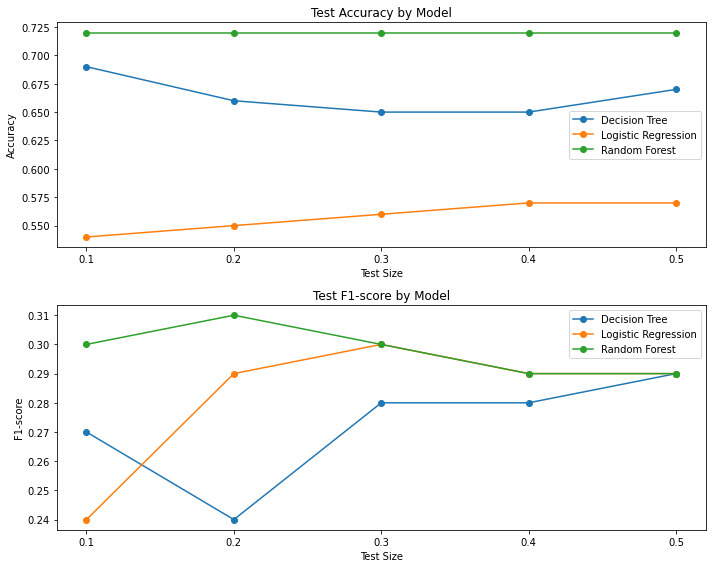

In [64]:
# Group performance metrics by model
grouped_performance = performance_df.groupby('Model')
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))

# Plot accuracy for each model
for name, group in grouped_performance:
    axes[0].plot(group['Test Size'], group['Accuracy'], marker='o', label=name)
axes[0].set_title('Test Accuracy by Model')
axes[0].set_xlabel('Test Size')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Plot F1 for each model
for name, group in grouped_performance:
    axes[1].plot(group['Test Size'], group['F1-score'], marker='o', label=name)
axes[1].set_title('Test F1-score by Model')
axes[1].set_xlabel('Test Size')
axes[1].set_ylabel('F1-score')
axes[1].legend()
for ax in axes:
    ax.set_xticks([0.1, 0.2, 0.3, 0.4, 0.5])

plt.tight_layout()
plt.show()

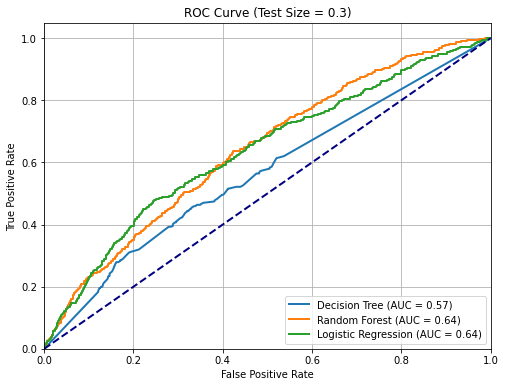

In [90]:
# Store the false positive rate (fpr) and true positive rate (tpr) of each model
all_fpr = []
all_tpr = []

# Initialize the plot
plt.figure(figsize=(8, 6))

# Iterate over each model in metric_records
for name in metric_records.keys():
    fpr = metric_records[name]['test_size_0.3_test']['fpr']
    tpr = metric_records[name]['test_size_0.3_test']['tpr']
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {metric_records[name]["test_size_0.3_test"]["auc"]:.2f})')
    all_fpr.append(fpr)
    all_tpr.append(tpr)

# Plot the diagonal reference line for random AUC
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Set the attributes of the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Size = 0.3)')
plt.legend(loc='lower right')
plt.grid(True)

# Display the plot
plt.show()